# EIGSEP Recovery v002: Canyon Forward Diagnostics

This notebook exercises the current `eigsep_sim` forward pipeline for the Marjum Canyon configuration. It is meant for correctness checks before fitting: sky maps, packaged terrain horizon maps, beam response, explicit masks, and effective sky weights are plotted for representative antenna orientations.

Run cells sequentially. The default resolution is intentionally modest so diagnostics are interactive; increase `NSIDE_SKY`, `N_AZ`, or `N_ALT` only after the plots look sane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy
from astropy.time import Time

from eigsep_sim import Sky, Beam, ForwardModel, HorizonTerrain
from eigsep_sim.observer import EarthSurface
from eigsep_sim.beam import BEAM_NPZ
from eigsep_sim.basis import BeamBasis

plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

# Marjum Canyon / EIGSEP scan configuration.
LAT_DEG = 39.2
LON_DEG = -113.4
HEIGHT_M = 1600.0
T_GND = 300.0
T_TX = 1e6
TX_DIR_TOP = np.array([0.0, 0.0, -1.0], dtype=np.float32)
OBS_TIME = Time("2025-06-21T04:00:00")

FREQS_HZ = np.linspace(50e6, 200e6, 20)
FREQS_MHZ = FREQS_HZ / 1e6
F_MID = len(FREQS_HZ) // 2

NSIDE_SKY = 16
N_SKY_MODES = 3
K_BEAM = 5
N_AZ = 36
N_ALT = 18

az_rad = np.linspace(0.0, 2 * np.pi, N_AZ, endpoint=False)
alt_rad = np.linspace(0.0, 2 * np.pi, N_ALT, endpoint=False)
az_deg = np.rad2deg(az_rad)
alt_deg = np.rad2deg(alt_rad)

TX_FREQS = FREQS_HZ[::4]
TX_POW = T_TX * np.ones_like(TX_FREQS)

print(f"Sky nside={NSIDE_SKY}, {len(FREQS_HZ)} frequencies, {N_AZ}x{N_ALT} orientations")

Sky nside=16, 20 frequencies, 36x18 orientations


In [2]:
def hp_moll(map_in, title, unit="", cmap="viridis", min=None, max=None, frame=None):
    """Display a HEALPix map and make its coordinate frame explicit."""
    map_in = np.asarray(map_in)
    nside = healpy.npix2nside(map_in.size)
    prefix = f"[{frame}] " if frame else ""
    healpy.mollview(
        map_in,
        title=f"{prefix}{title} (nside={nside})",
        unit=unit,
        cmap=cmap,
        min=min,
        max=max,
        hold=False,
    )
    healpy.graticule(alpha=0.25)


def top2body_grid(az_values, alt_values):
    rots = []
    labels = []
    for az in az_values:
        for alt in alt_values:
            rots.append(Beam.top2body(az, alt))
            labels.append((az, alt))
    return rots, labels


def hp_vectors(nside):
    pix = np.arange(healpy.nside2npix(nside))
    return np.stack(healpy.pix2vec(nside, pix), axis=0).astype(np.float32)


def nearest_beam_on_sky(beam_map, beam_nside, crds_body):
    pix = healpy.vec2pix(beam_nside, crds_body[0], crds_body[1], crds_body[2])
    return beam_map[pix]


def orientation_index(i_az, i_alt):
    return i_az * N_ALT + i_alt


def normalize_weights(w):
    total = np.nansum(w)
    return w / total if total > 0 else w

## Build Observer, Terrain, Beam, And Sky

The surface observer does not impose an implicit `z > 0` cut. The packaged Marjum horizon model is the explicit sky blocker; omitted pixels in reduced `sky_mask` geometry use the terrain unresolved-emission contract.

In [3]:
observer = EarthSurface(lat=LAT_DEG, lon=LON_DEG, height=HEIGHT_M)
observer.set_time(OBS_TIME)
R_GAL2TOP = observer.rot_gal2top().astype(np.float32)

terrain = HorizonTerrain.from_packaged_model(height=100.0, T_terrain=T_GND)
print(f"Terrain nside={terrain.nside}, height slice={terrain.height} m")
print(f"Terrain horizon finite fraction={np.isfinite(terrain.horizon_map).mean():.3f}")

beam_basis, beam_coeffs = BeamBasis.from_beam_file(BEAM_NPZ, FREQS_HZ, K_BEAM)
beam_nside = healpy.npix2nside(beam_coeffs.shape[1])
beam = Beam(
    beam_nside,
    FREQS_HZ,
    beam_basis,
    beam_coeffs,
    u_body=np.array([[1.0, 0.0, 0.0]], dtype=np.float32),
)
print(f"Beam nside={beam.nside}, npix={beam.npix}, modes={beam.nmodes}")

sky = Sky.from_gsm(NSIDE_SKY, FREQS_HZ, n_modes=N_SKY_MODES)
sky_coeffs = sky.init_coeffs()
sky_maps = sky_coeffs @ sky.basis.A.T
print(f"Sky coeffs={sky_coeffs.shape}, reconstructed maps={sky_maps.shape}")

fwd = ForwardModel(
    observer,
    beam,
    sky,
    terrain=terrain,
    transmitters=[(TX_DIR_TOP, TX_FREQS, TX_POW)],
)

Terrain nside=64, height slice=101.44444444444444 m
Terrain horizon finite fraction=0.666


Beam nside=64, npix=49152, modes=5


Sky coeffs=(3072, 4), reconstructed maps=(3072, 20)


## Static Diagnostics: Sky, Terrain, Beam

These plots check the three model ingredients before any scan rotation is applied.

<Figure size 1440x960 with 0 Axes>

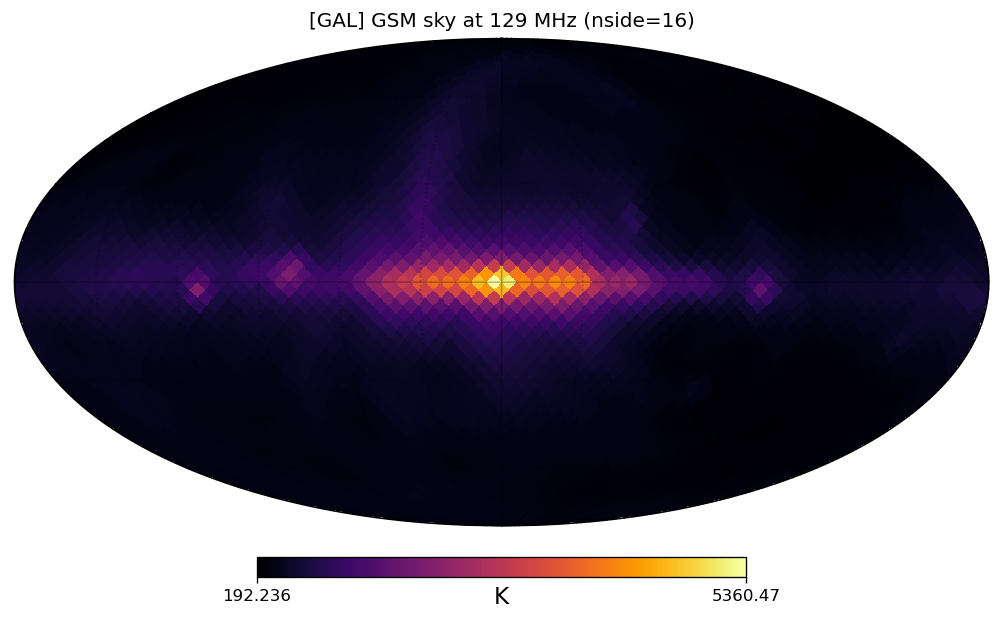

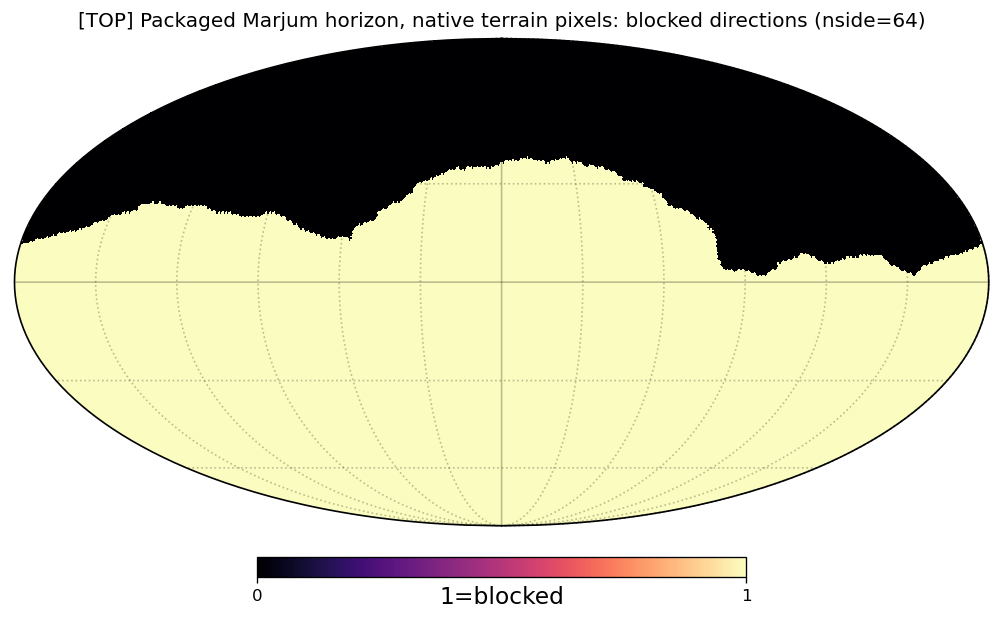

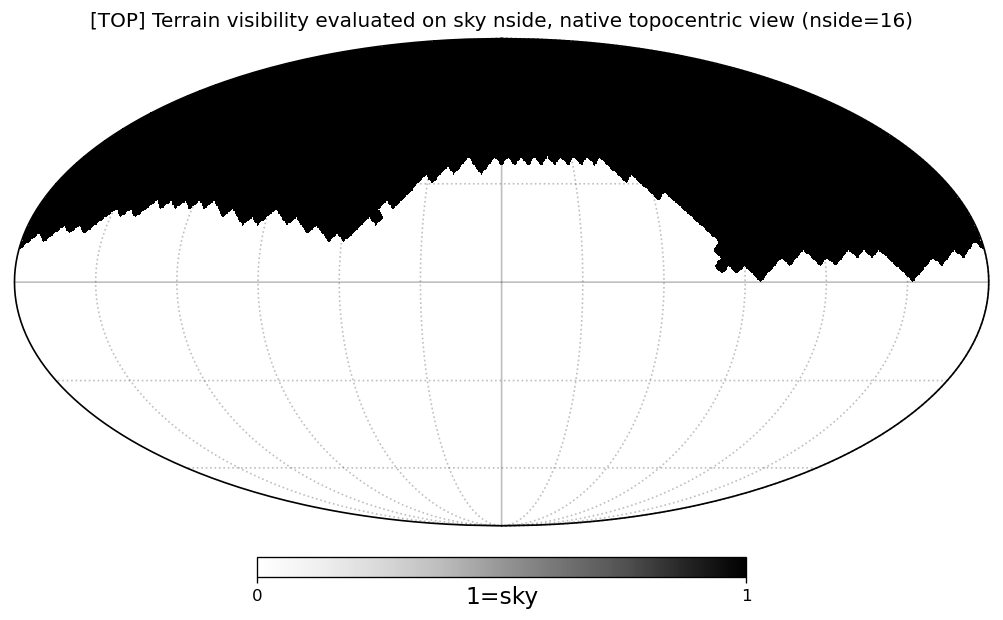

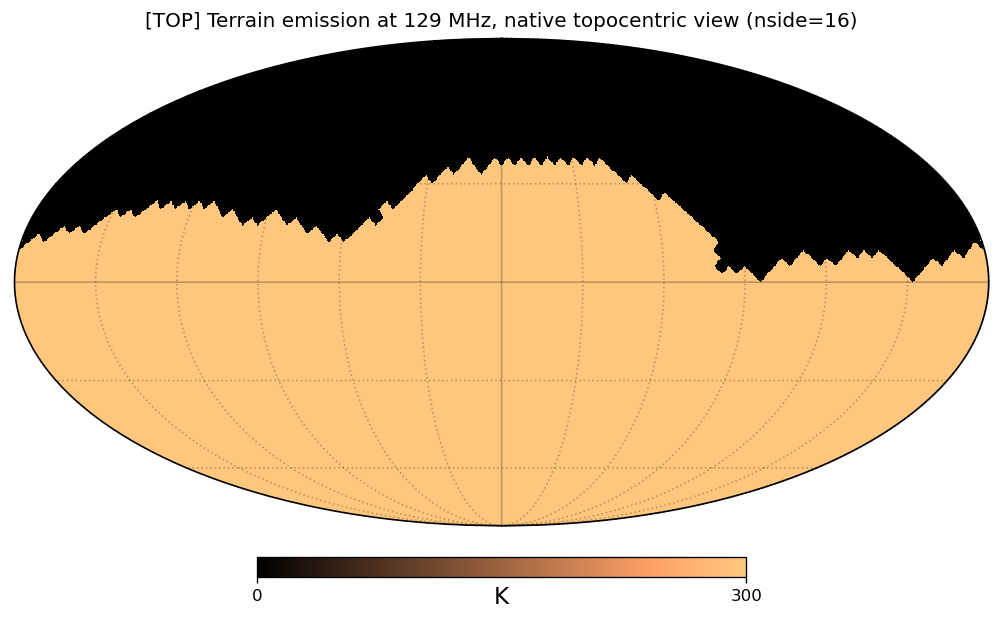

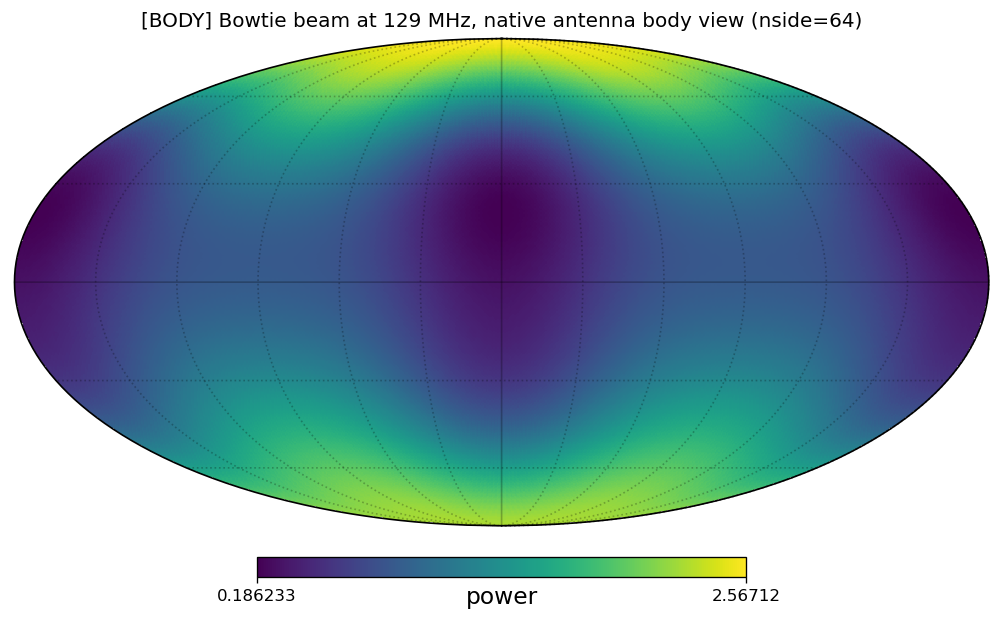

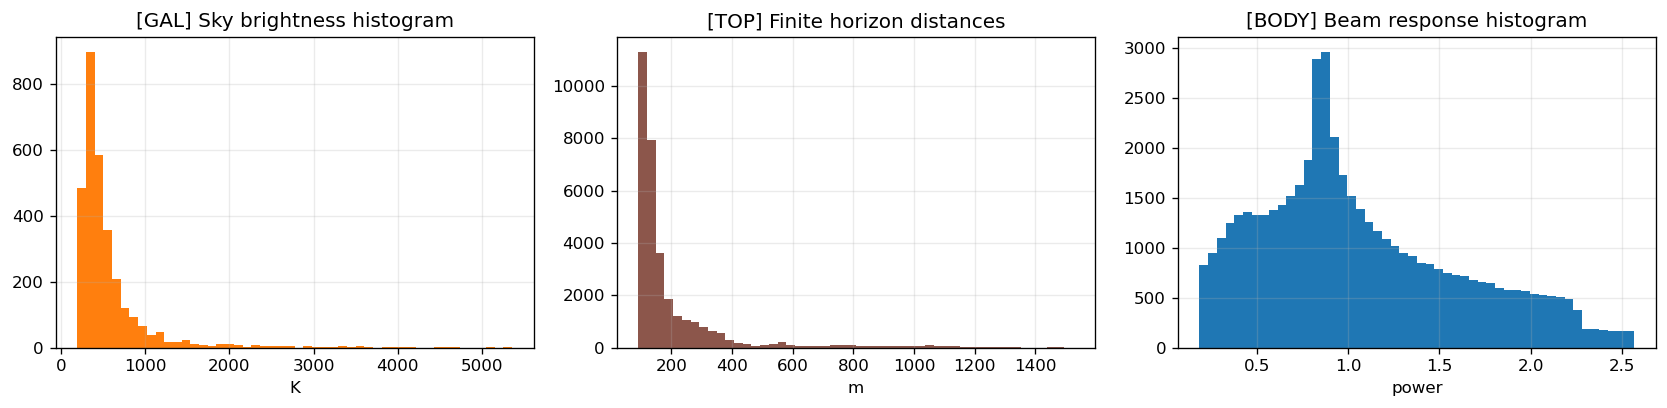

In [4]:
# Native-frame maps. These are not rotated into another coordinate system.
# [GAL] Galactic HEALPix: sky model coefficients live in this frame.
# [TOP] Topocentric HEALPix: terrain horizon model lives in this local ENU frame.
# [BODY] Antenna body HEALPix: beam coefficients live in this frame.
fig = plt.figure(figsize=(12, 8))
hp_moll(
    sky_maps[:, F_MID],
    f"GSM sky at {FREQS_MHZ[F_MID]:.0f} MHz",
    unit="K",
    cmap="inferno",
    frame="GAL",
)
plt.show()

horizon_blocked_native = np.isfinite(terrain.horizon_map).astype(float)
hp_moll(
    horizon_blocked_native,
    "Packaged Marjum horizon, native terrain pixels: blocked directions",
    unit="1=blocked",
    cmap="magma",
    min=0,
    max=1,
    frame="TOP",
)
plt.show()

# Evaluate terrain on the sky resolution as a topocentric map using the
# same nearest-neighbor categorical lookup as ForwardModel geometry.
top_crds_sky_nside = hp_vectors(NSIDE_SKY)
top_visible_native = terrain.mask(top_crds_sky_nside).astype(float)
top_emission_native = terrain.emission(top_crds_sky_nside, FREQS_HZ)[:, F_MID]
hp_moll(
    top_visible_native,
    "Terrain visibility evaluated on sky nside, native topocentric view",
    unit="1=sky",
    cmap="Greys",
    min=0,
    max=1,
    frame="TOP",
)
plt.show()
hp_moll(
    top_emission_native,
    f"Terrain emission at {FREQS_MHZ[F_MID]:.0f} MHz, native topocentric view",
    unit="K",
    cmap="copper",
    frame="TOP",
)
plt.show()

beam_mid = beam.evaluate(F_MID)[0]
hp_moll(
    beam_mid,
    f"Bowtie beam at {FREQS_MHZ[F_MID]:.0f} MHz, native antenna body view",
    unit="power",
    cmap="viridis",
    frame="BODY",
)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(sky_maps[:, F_MID], bins=50, color="tab:orange")
axes[0].set_title("[GAL] Sky brightness histogram")
axes[0].set_xlabel("K")
axes[1].hist(terrain.horizon_map[np.isfinite(terrain.horizon_map)], bins=50, color="tab:brown")
axes[1].set_title("[TOP] Finite horizon distances")
axes[1].set_xlabel("m")
axes[2].hist(beam_mid, bins=50, color="tab:blue")
axes[2].set_title("[BODY] Beam response histogram")
axes[2].set_xlabel("power")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()

## Geometry And Masks For Representative Orientations

The diagnostics below inspect the exact geometry arrays passed to the JAX scan. `terrain_masks_jax` is the visibility factor for sampled sky pixels. `terrain_emissions_jax` is the terrain brightness for explicitly sampled blocked pixels. Reduced geometry is compared to full geometry later.

In [5]:
body_rots_scan, orient_labels = top2body_grid(az_rad, alt_rad)
rots_scan = [R_GAL2TOP] * len(body_rots_scan)

sky_mask = fwd.build_sky_mask(rots=rots_scan)
print(f"Ever-visible pixels: {sky_mask.sum()} / {sky_mask.size} ({sky_mask.mean():.3f})")

geom_full = fwd.precompute_geometry(rots=rots_scan, body_rots=body_rots_scan)
geom_mask = fwd.precompute_geometry(rots=rots_scan, body_rots=body_rots_scan, sky_mask=sky_mask)

print("Full geometry:")
for key in ["terrain_masks_jax", "terrain_emissions_jax", "default_emission_masks_jax", "crds_gal_jax", "tx_crds_jax"]:
    print(f"  {key}: {tuple(geom_full[key].shape)}")
print("Reduced geometry:")
for key in ["terrain_masks_jax", "terrain_emissions_jax", "default_emission_masks_jax", "crds_gal_jax", "tx_crds_jax"]:
    print(f"  {key}: {tuple(geom_mask[key].shape)}")

Ever-visible pixels: 1029 / 3072 (0.335)


Full geometry:
  terrain_masks_jax: (648, 3072)
  terrain_emissions_jax: (648, 3072, 20)
  default_emission_masks_jax: (648, 3072)
  crds_gal_jax: (3, 3072)
  tx_crds_jax: (648, 1, 3)
Reduced geometry:
  terrain_masks_jax: (648, 1029)
  terrain_emissions_jax: (648, 1029, 20)
  default_emission_masks_jax: (648, 1029)
  crds_gal_jax: (3, 1029)
  tx_crds_jax: (648, 1, 3)


Orientation 0: az=0 deg, alt=0 deg
  display [GAL]: values indexed by Galactic sky pixels
  evaluation: sky GAL -> TOP for terrain -> BODY for beam


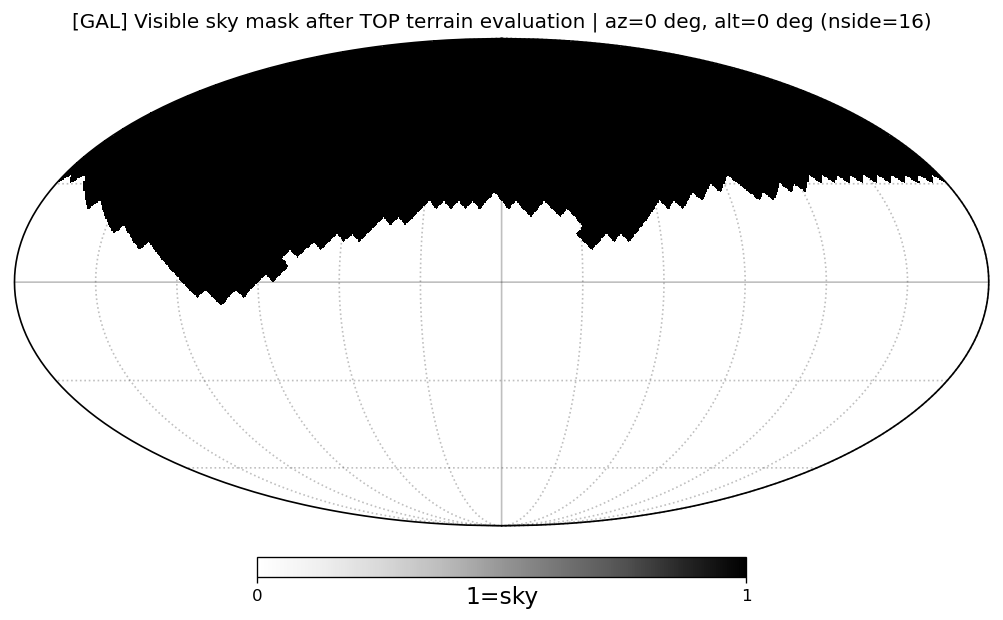

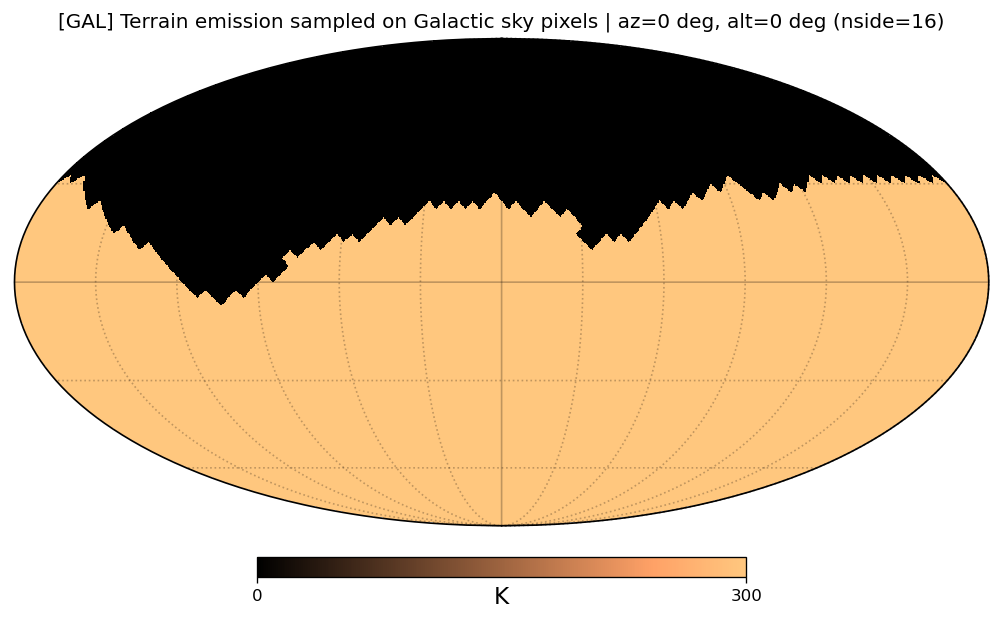

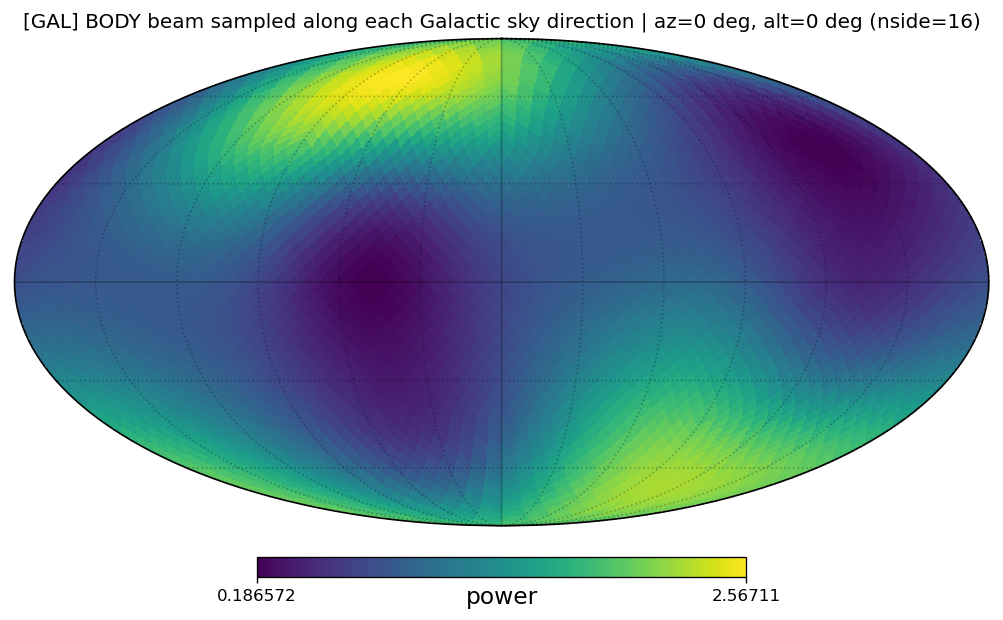

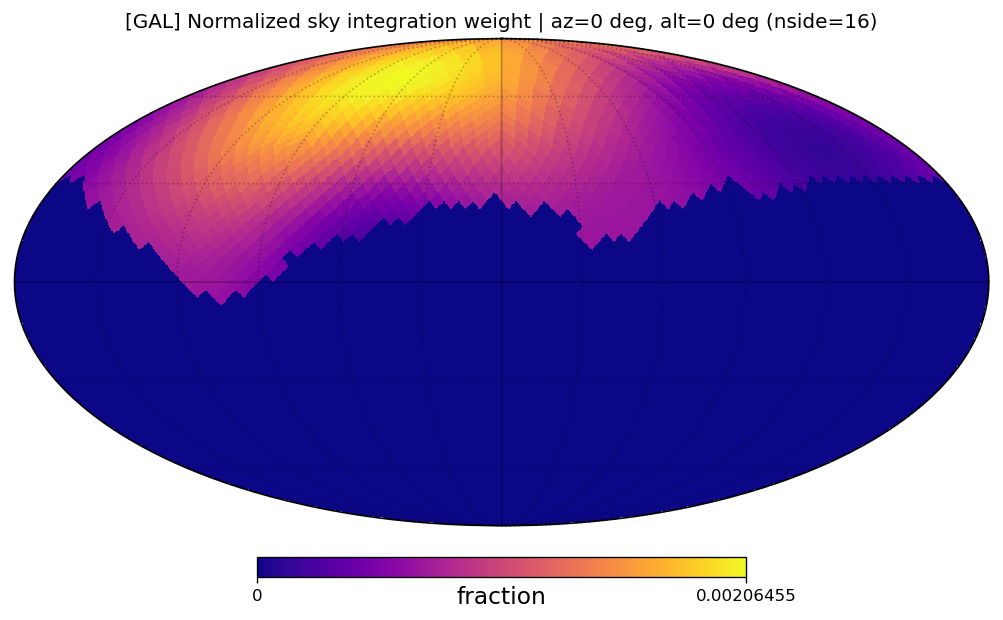

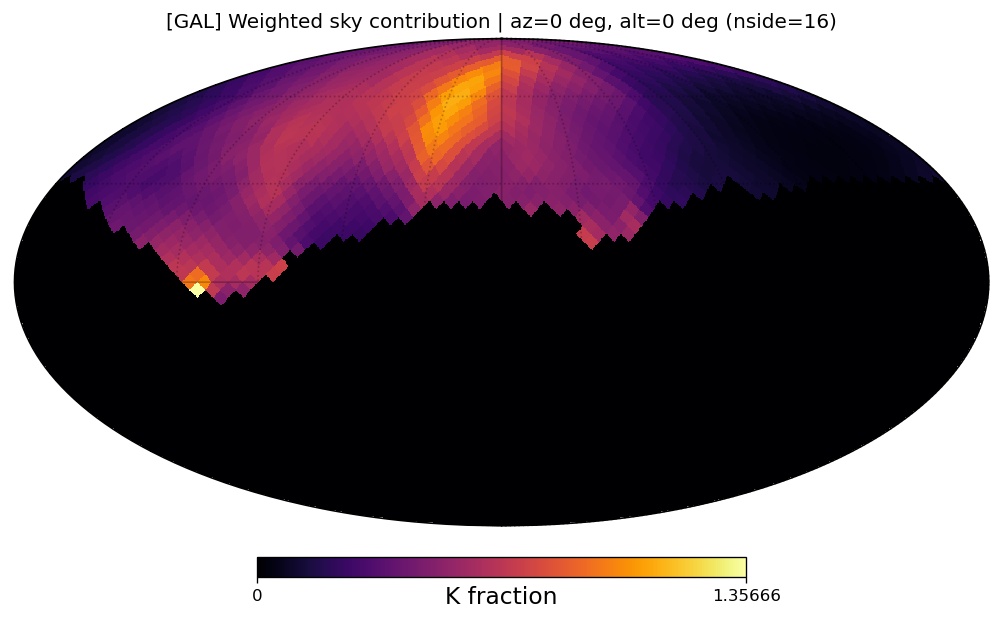

Orientation 162: az=90 deg, alt=0 deg
  display [GAL]: values indexed by Galactic sky pixels
  evaluation: sky GAL -> TOP for terrain -> BODY for beam


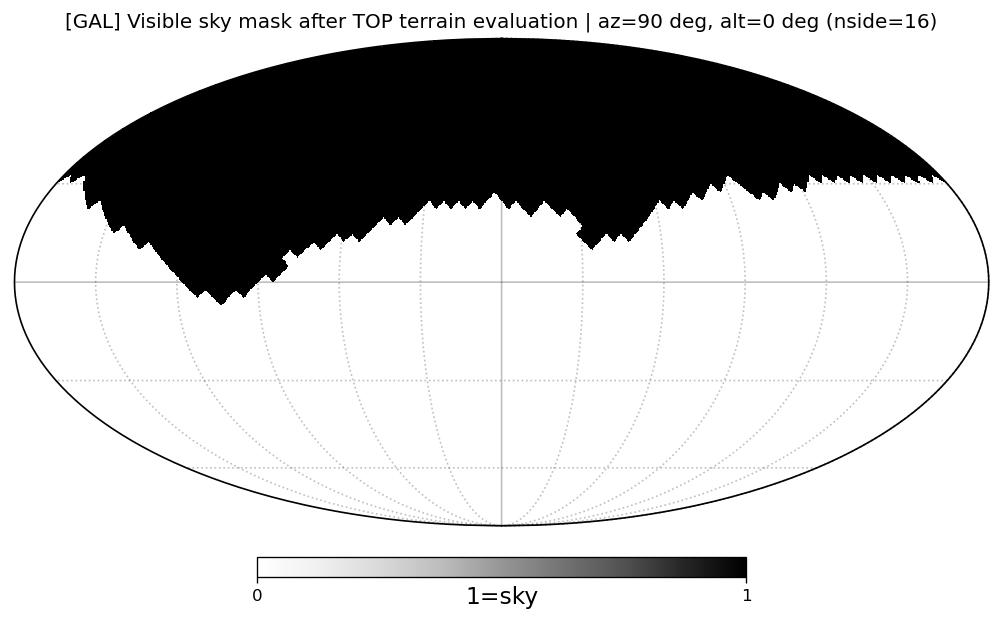

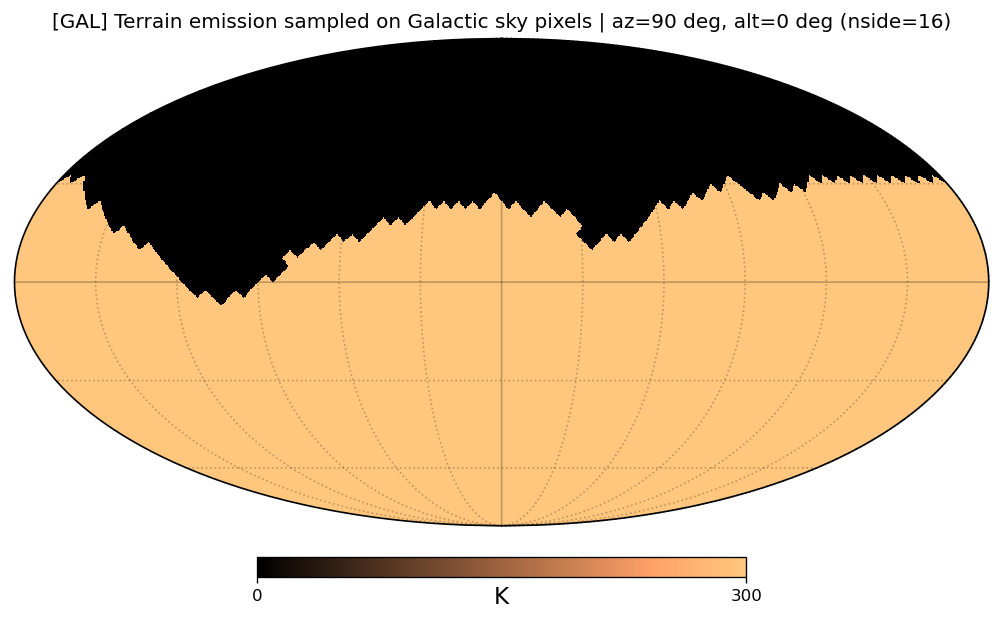

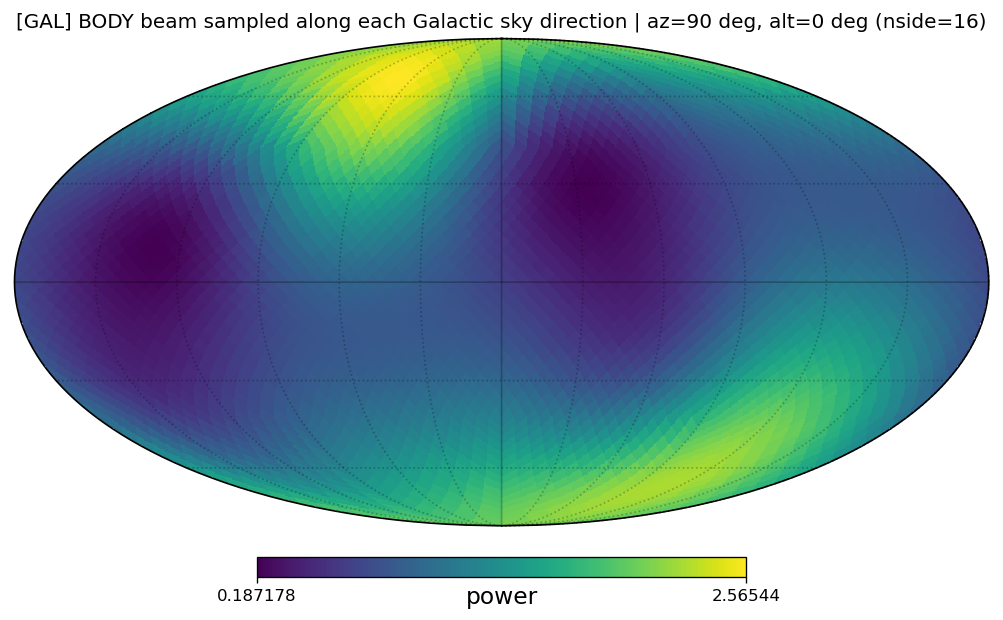

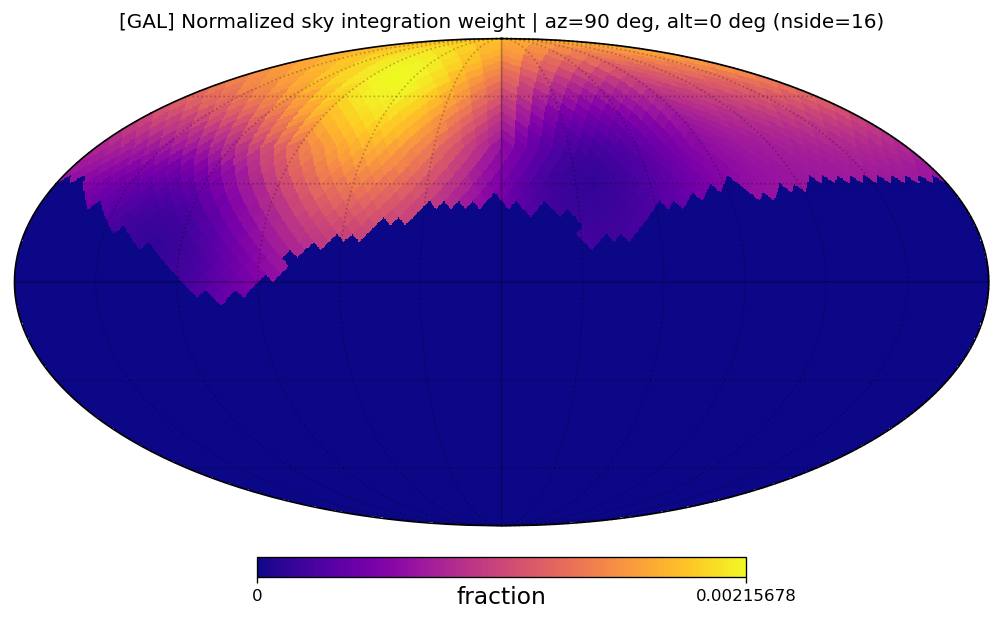

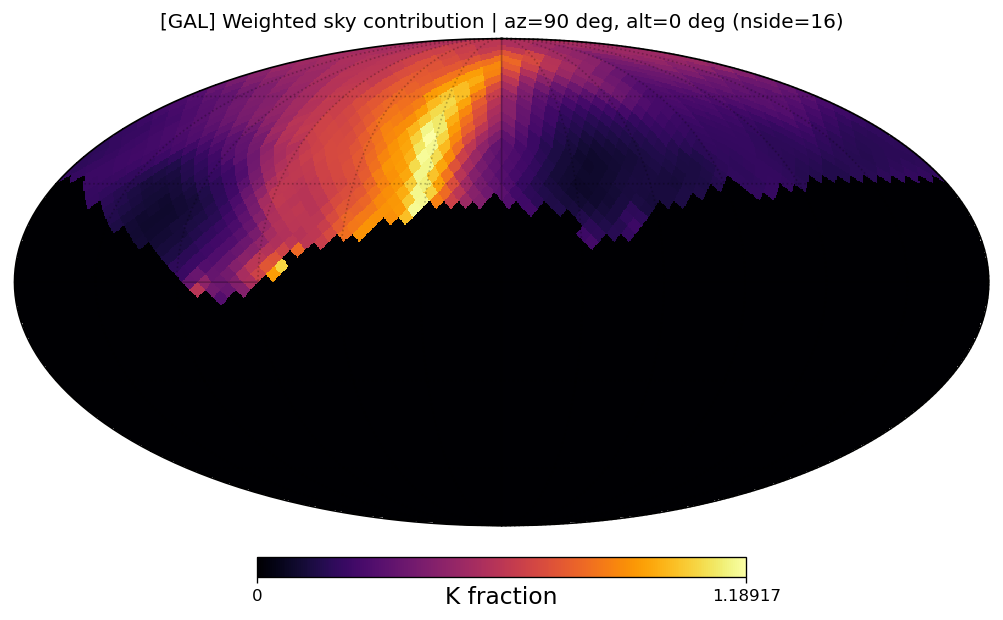

Orientation 4: az=0 deg, alt=80 deg
  display [GAL]: values indexed by Galactic sky pixels
  evaluation: sky GAL -> TOP for terrain -> BODY for beam


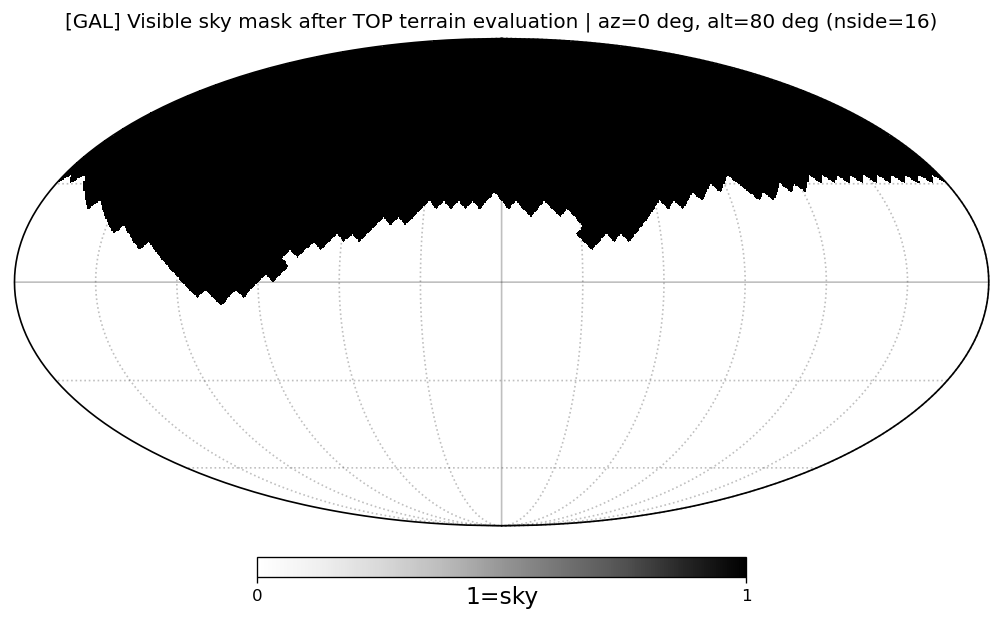

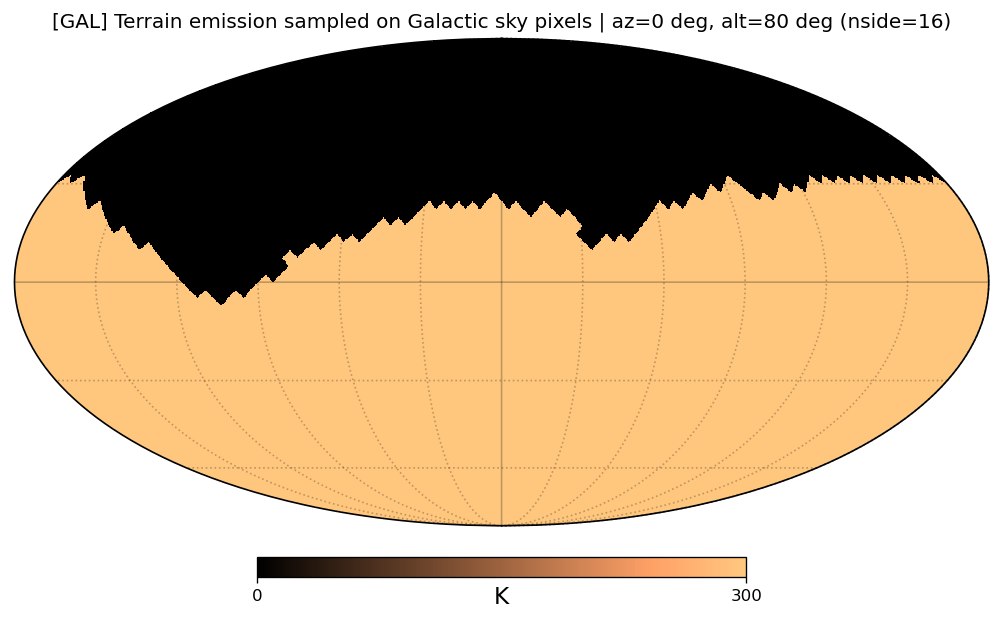

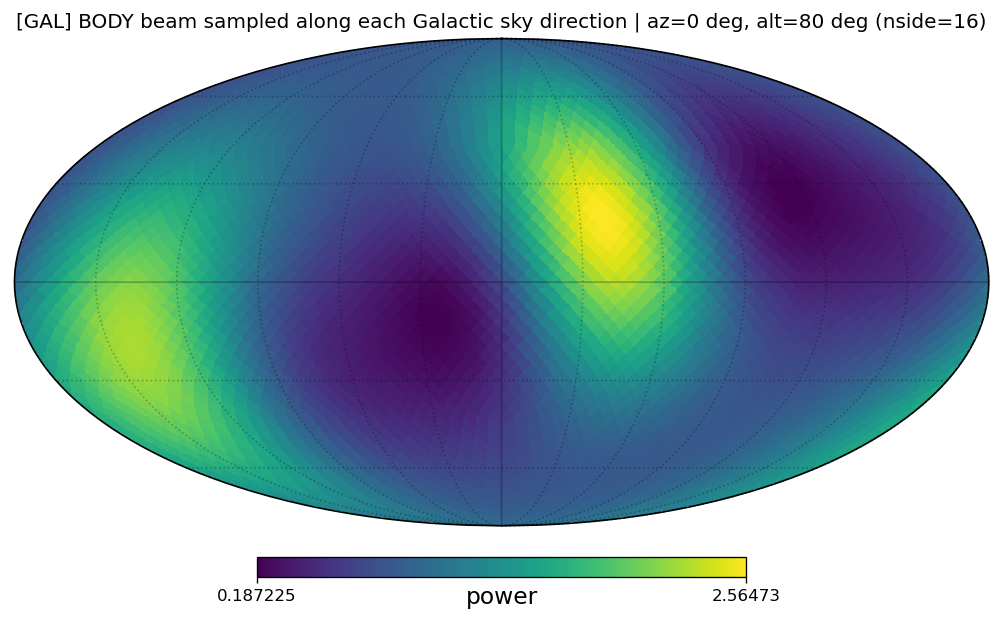

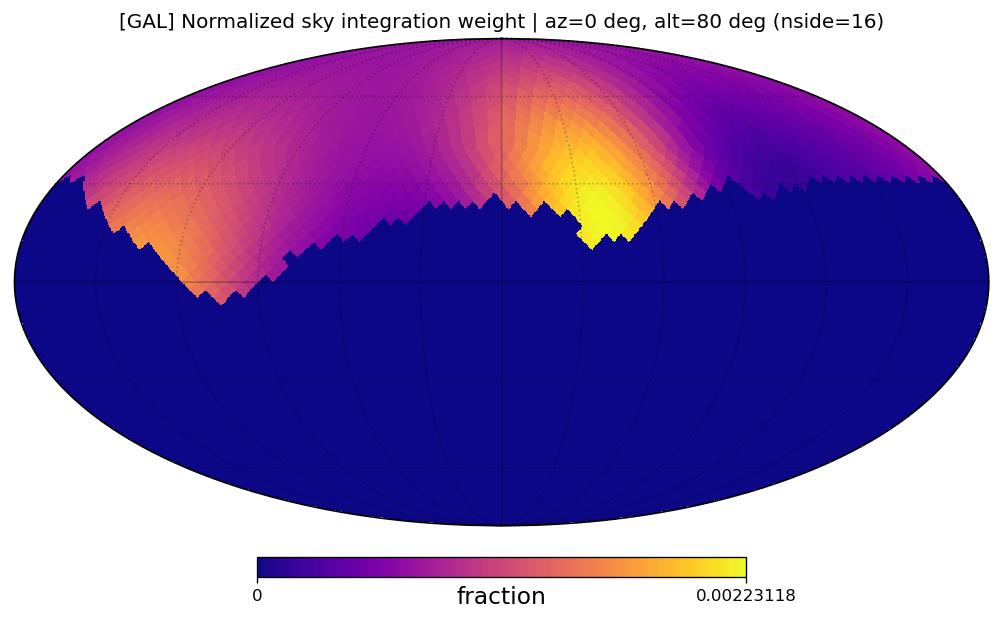

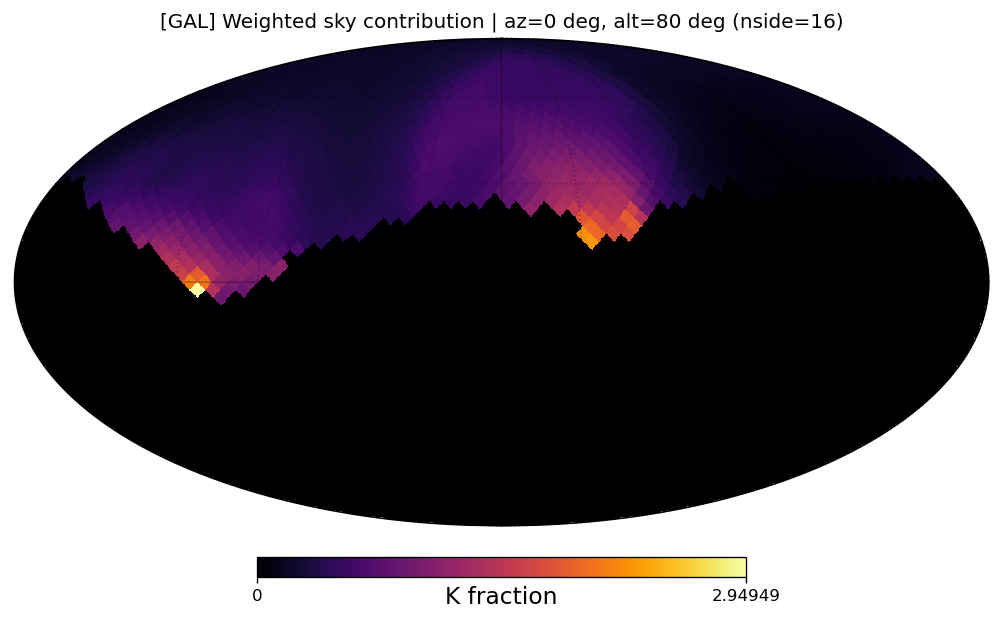

Orientation 333: az=180 deg, alt=180 deg
  display [GAL]: values indexed by Galactic sky pixels
  evaluation: sky GAL -> TOP for terrain -> BODY for beam


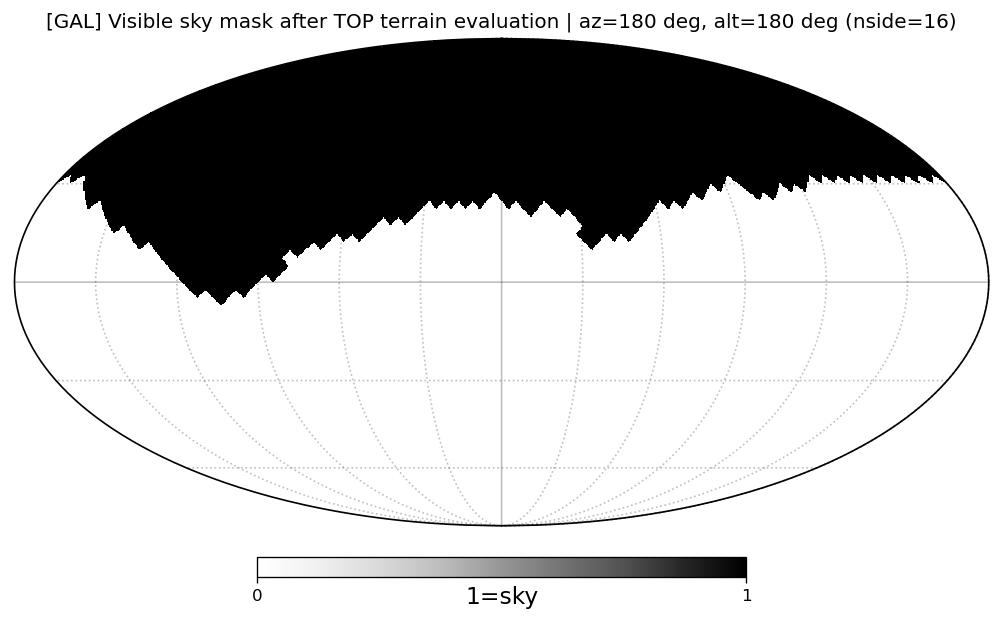

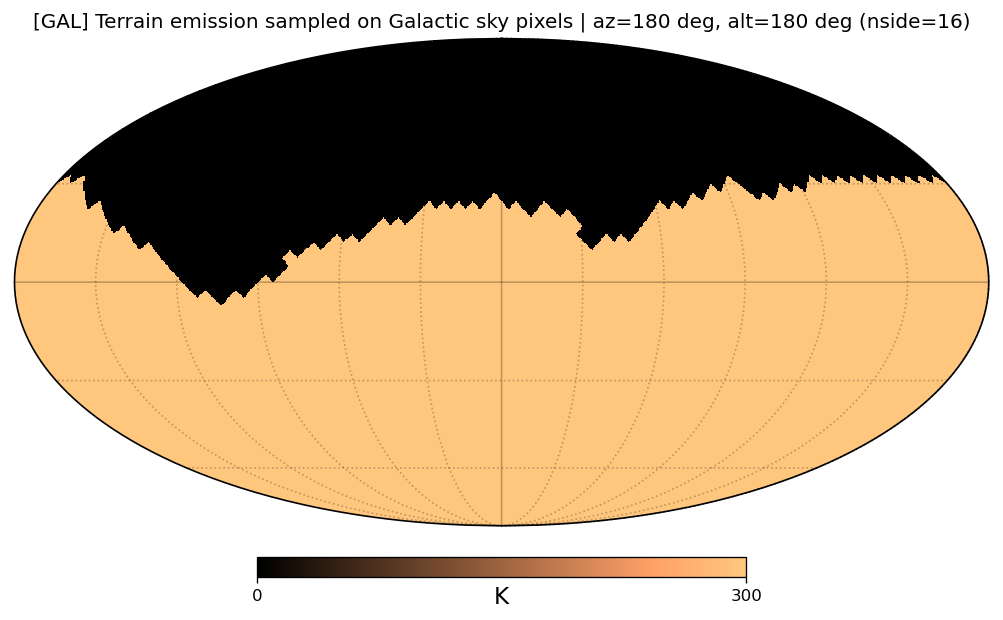

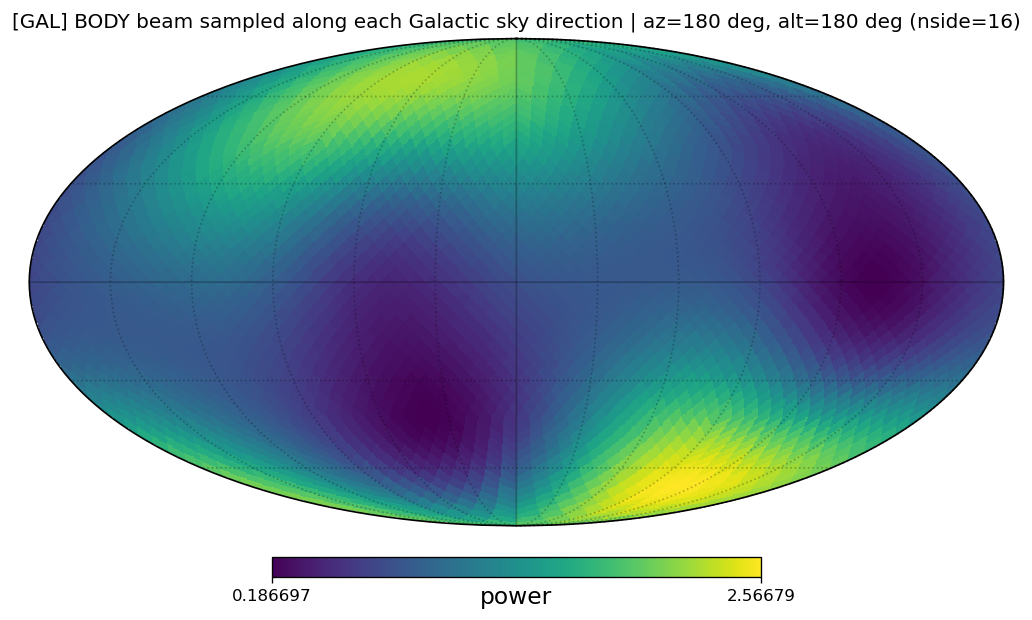

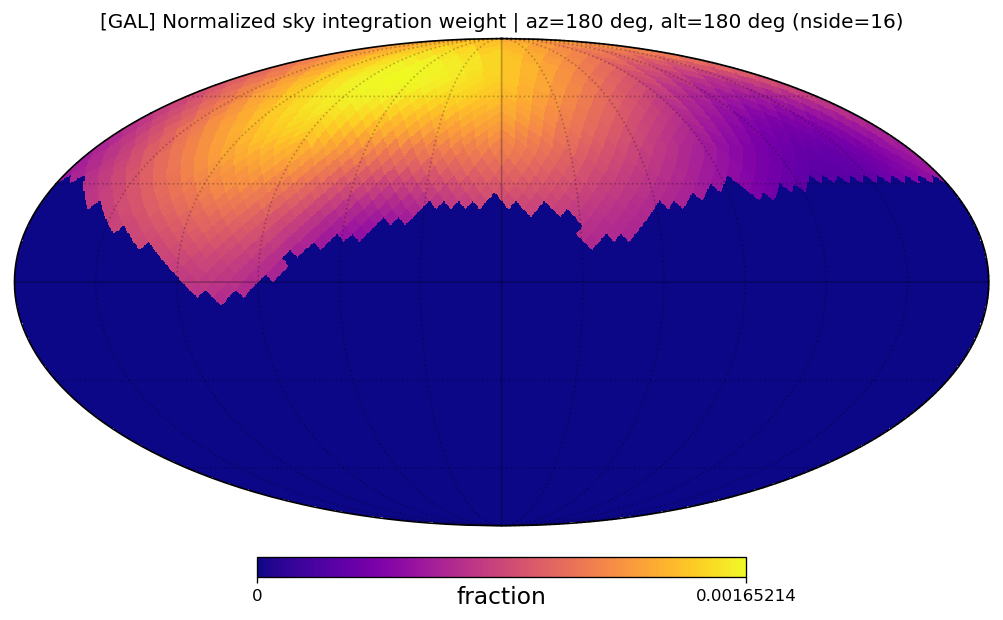

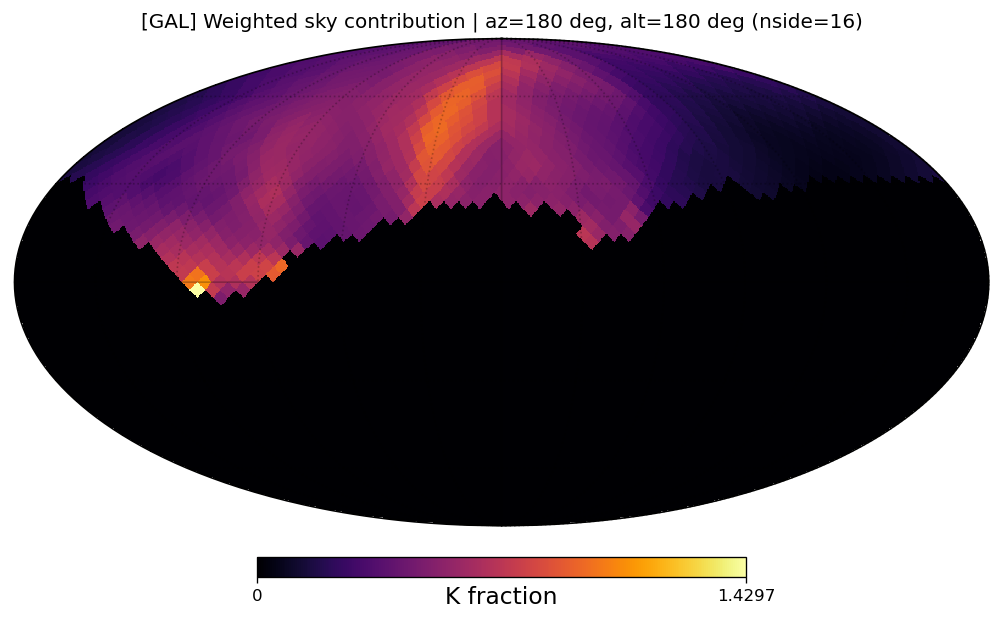

In [6]:
# Rebuild scan geometry if this cell is run after a kernel restart.
if "body_rots_scan" not in globals() or "orient_labels" not in globals():
    body_rots_scan, orient_labels = top2body_grid(az_rad, alt_rad)
if "geom_full" not in globals():
    rots_scan = [R_GAL2TOP] * len(body_rots_scan)
    geom_full = fwd.precompute_geometry(rots=rots_scan, body_rots=body_rots_scan)

diagnostic_orients = [
    (0, 0),
    (N_AZ // 4, 0),
    (0, N_ALT // 4),
    (N_AZ // 2, N_ALT // 2),
]

crds_gal = hp_vectors(NSIDE_SKY)
crds_top = R_GAL2TOP @ crds_gal

for i_az, i_alt in diagnostic_orients:
    idx = orientation_index(i_az, i_alt)
    az, alt = orient_labels[idx]
    body_rot = body_rots_scan[idx]
    crds_body = body_rot @ crds_top

    # These arrays are indexed by Galactic sky pixels. The terrain values were
    # evaluated after rotating each Galactic pixel into TOP coordinates.
    visible_gal_indexed = np.asarray(geom_full["terrain_masks_jax"])[idx]
    terrain_emit_gal_indexed = np.asarray(geom_full["terrain_emissions_jax"])[idx, :, F_MID]
    beam_on_gal_pixels = nearest_beam_on_sky(beam_mid, beam.nside, crds_body)
    effective_weight_gal = normalize_weights(beam_on_gal_pixels * visible_gal_indexed)
    sky_contribution_gal = effective_weight_gal * sky_maps[:, F_MID]

    title = f"az={np.rad2deg(az):.0f} deg, alt={np.rad2deg(alt):.0f} deg"
    print(f"Orientation {idx}: {title}")
    print("  display [GAL]: values indexed by Galactic sky pixels")
    print("  evaluation: sky GAL -> TOP for terrain -> BODY for beam")

    hp_moll(
        visible_gal_indexed,
        f"Visible sky mask after TOP terrain evaluation | {title}",
        unit="1=sky",
        cmap="Greys",
        min=0,
        max=1,
        frame="GAL",
    )
    plt.show()
    hp_moll(
        terrain_emit_gal_indexed,
        f"Terrain emission sampled on Galactic sky pixels | {title}",
        unit="K",
        cmap="copper",
        frame="GAL",
    )
    plt.show()
    hp_moll(
        beam_on_gal_pixels,
        f"BODY beam sampled along each Galactic sky direction | {title}",
        unit="power",
        cmap="viridis",
        frame="GAL",
    )
    plt.show()
    hp_moll(
        effective_weight_gal,
        f"Normalized sky integration weight | {title}",
        unit="fraction",
        cmap="plasma",
        frame="GAL",
    )
    plt.show()
    hp_moll(
        sky_contribution_gal,
        f"Weighted sky contribution | {title}",
        unit="K fraction",
        cmap="inferno",
        frame="GAL",
    )
    plt.show()

## Forward Simulation Checks

This cell simulates full and reduced geometry. Agreement between the two checks that the `sky_mask` omitted-pixel accounting is consistent with the explicit terrain model.

In [7]:
print("Simulating full geometry ...", flush=True)
T_full = np.array(fwd.simulate(sky_coeffs, beam.coeffs, geom=geom_full, T_gnd=T_GND))[:, 0, :]
print("Simulating reduced sky-mask geometry ...", flush=True)
T_mask = np.array(fwd.simulate(sky_coeffs, beam.coeffs, geom=geom_mask, T_gnd=T_GND))[:, 0, :]

max_abs = np.max(np.abs(T_full - T_mask))
rel = max_abs / max(np.max(np.abs(T_full)), 1.0)
print(f"max |full - masked| = {max_abs:.3e} K ({rel:.3e} relative)")

T_grid = T_full.reshape(N_AZ, N_ALT, len(FREQS_HZ))
T_diff_grid = (T_full - T_mask).reshape(N_AZ, N_ALT, len(FREQS_HZ))

Simulating full geometry ...


Simulating reduced sky-mask geometry ...


max |full - masked| = 1.124e-03 K (3.208e-10 relative)


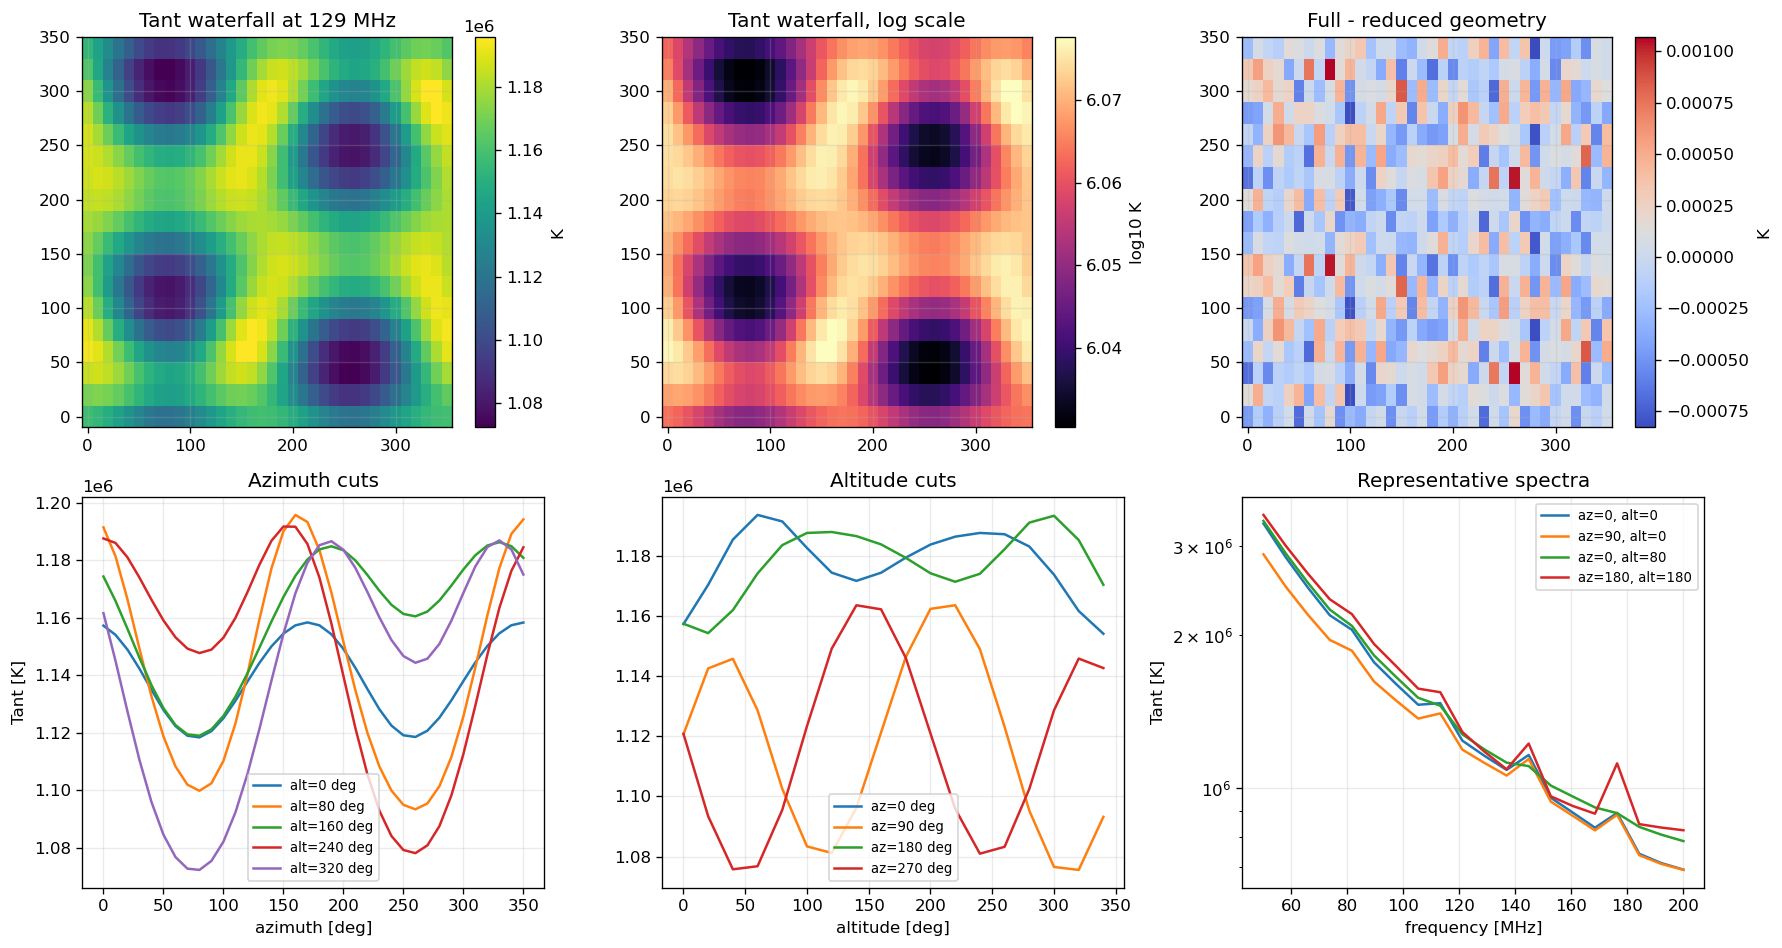

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

im = axes[0, 0].pcolormesh(az_deg, alt_deg, T_grid[:, :, F_MID].T, shading="nearest", cmap="viridis")
plt.colorbar(im, ax=axes[0, 0], label="K")
axes[0, 0].set_title(f"Tant waterfall at {FREQS_MHZ[F_MID]:.0f} MHz")

im = axes[0, 1].pcolormesh(az_deg, alt_deg, np.log10(np.maximum(T_grid[:, :, F_MID].T, 1e-6)), shading="nearest", cmap="magma")
plt.colorbar(im, ax=axes[0, 1], label="log10 K")
axes[0, 1].set_title("Tant waterfall, log scale")

im = axes[0, 2].pcolormesh(az_deg, alt_deg, T_diff_grid[:, :, F_MID].T, shading="nearest", cmap="coolwarm")
plt.colorbar(im, ax=axes[0, 2], label="K")
axes[0, 2].set_title("Full - reduced geometry")

for i_alt in range(0, N_ALT, max(1, N_ALT // 4)):
    axes[1, 0].plot(az_deg, T_grid[:, i_alt, F_MID], label=f"alt={alt_deg[i_alt]:.0f} deg")
axes[1, 0].set_title("Azimuth cuts")
axes[1, 0].set_xlabel("azimuth [deg]")
axes[1, 0].set_ylabel("Tant [K]")
axes[1, 0].legend(fontsize=8)

for i_az in range(0, N_AZ, max(1, N_AZ // 4)):
    axes[1, 1].plot(alt_deg, T_grid[i_az, :, F_MID], label=f"az={az_deg[i_az]:.0f} deg")
axes[1, 1].set_title("Altitude cuts")
axes[1, 1].set_xlabel("altitude [deg]")
axes[1, 1].legend(fontsize=8)

for i_az, i_alt in diagnostic_orients:
    idx = orientation_index(i_az, i_alt)
    axes[1, 2].semilogy(FREQS_MHZ, T_full[idx], label=f"az={az_deg[i_az]:.0f}, alt={alt_deg[i_alt]:.0f}")
axes[1, 2].set_title("Representative spectra")
axes[1, 2].set_xlabel("frequency [MHz]")
axes[1, 2].set_ylabel("Tant [K]")
axes[1, 2].legend(fontsize=8)

for ax in axes.ravel():
    ax.grid(alpha=0.25)
plt.tight_layout()

## Fit-Oriented Diagnostics

These summary plots expose the conditioning ingredients used by a recovery: per-orientation visible sky fraction, beam solid angle on the visible sky, terrain-emission weight, and transmitter-only contribution. Large discontinuities or impossible symmetries here usually point to rotation, mask, or beam-frame mistakes before a fit is attempted.

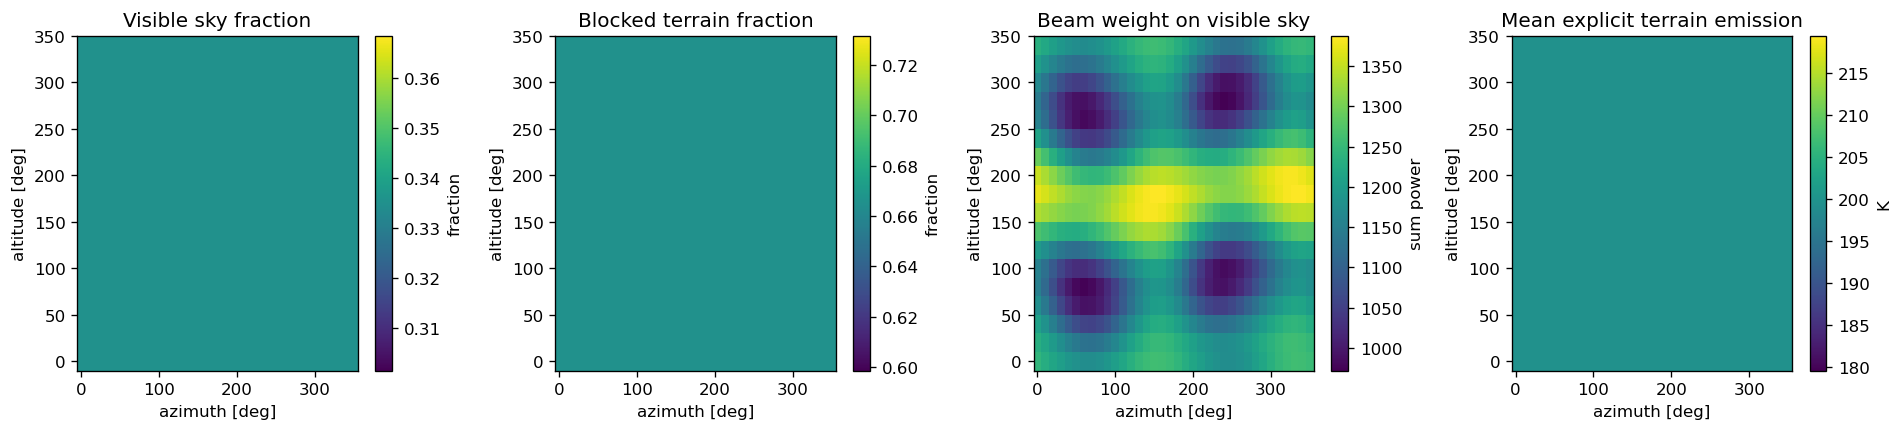

In [9]:
masks = np.asarray(geom_full["terrain_masks_jax"])
terrain_emit_mid = np.asarray(geom_full["terrain_emissions_jax"])[:, :, F_MID]
crds_top_all = np.asarray(geom_full["rots_jax"]) @ crds_gal

visible_fraction = masks.mean(axis=1).reshape(N_AZ, N_ALT)
terrain_fraction = (1.0 - masks).mean(axis=1).reshape(N_AZ, N_ALT)
terrain_emit_mean = terrain_emit_mid.mean(axis=1).reshape(N_AZ, N_ALT)

beam_visible_sum = []
for idx, body_rot in enumerate(body_rots_scan):
    beam_sky = nearest_beam_on_sky(beam_mid, beam.nside, body_rot @ crds_top)
    beam_visible_sum.append(np.sum(beam_sky * masks[idx]))
beam_visible_sum = np.array(beam_visible_sum).reshape(N_AZ, N_ALT)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.7))
for ax, arr, title, label in [
    (axes[0], visible_fraction, "Visible sky fraction", "fraction"),
    (axes[1], terrain_fraction, "Blocked terrain fraction", "fraction"),
    (axes[2], beam_visible_sum, "Beam weight on visible sky", "sum power"),
    (axes[3], terrain_emit_mean, "Mean explicit terrain emission", "K"),
]:
    im = ax.pcolormesh(az_deg, alt_deg, arr.T, shading="nearest")
    plt.colorbar(im, ax=ax, label=label)
    ax.set_title(title)
    ax.set_xlabel("azimuth [deg]")
    ax.set_ylabel("altitude [deg]")
plt.tight_layout()

check                                        loss      / nominal
----------------------------------------------------------------
nominal                                 9.939e-01      1.000e+00
sky amplitude +10%                      1.416e+10      1.424e+10
beam shape z-modulation 10%             2.699e+09      2.715e+09
terrain temperature +10%                3.218e+09      3.238e+09
terrain mask removed                    5.175e+12      5.207e+12


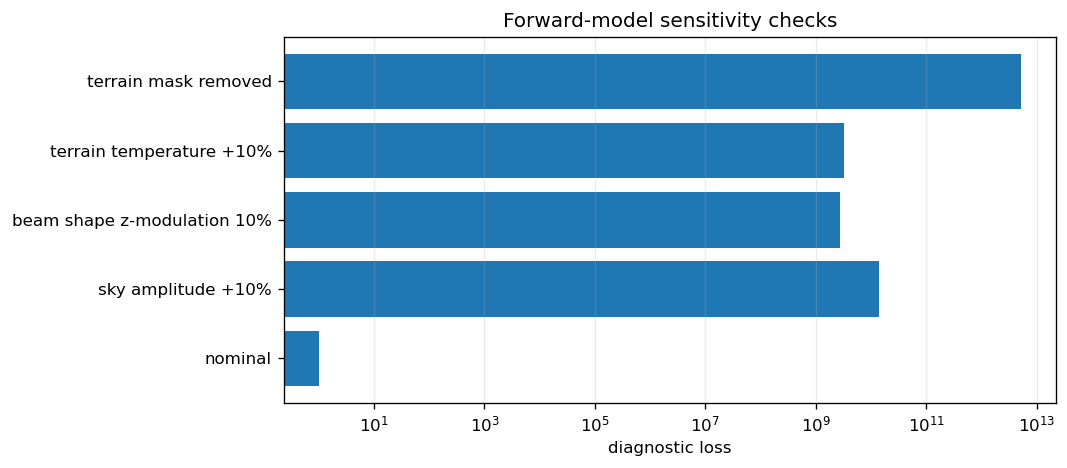

In [10]:
# Lightweight recovery sensitivity checks. These should distinguish model-error
# classes before running an expensive fit.
from eigsep_sim import Calibrator
import jax.numpy as jnp

rng = np.random.default_rng(0)
noise_sigma = 1.0  # K, diagnostic scale only
mock_data = T_full[:, None, :] + rng.normal(
    0.0, noise_sigma, size=T_full[:, None, :].shape
).astype(np.float32)
cal = Calibrator(
    fwd,
    mock_data,
    inv_noise_var=np.ones_like(mock_data) / noise_sigma**2,
    lam_beam=0.01,
    # The harmonic beam prior builds a dense (npix, npix) operator; at the
    # measured beam nside it is infeasible (and unused here), so disable it.
    lam_beam_harmonic=0.0,
)
params_nom = cal.init_params(geom=geom_full)
params_nom["sky_coeffs"] = sky_coeffs.copy()
params_nom["beam_coeffs"] = beam.coeffs.copy()


def clone_params(params):
    return {key: np.array(value, copy=True) for key, value in params.items()}


def loss_with_geom(params, geom):
    cal._geom = geom
    return float(cal._loss(params))


checks = {}
checks["nominal"] = loss_with_geom(params_nom, geom_full)

params_bad_sky = clone_params(params_nom)
params_bad_sky["sky_coeffs"] *= 1.10
checks["sky amplitude +10%"] = loss_with_geom(params_bad_sky, geom_full)

# Do not scale the whole beam: Tant normalization largely cancels that mode.
# Instead perturb beam shape in the antenna BODY frame.
beam_body_z = hp_vectors(beam.nside)[2]
params_bad_beam = clone_params(params_nom)
params_bad_beam["beam_coeffs"][:, :, 0] *= 1.0 + 0.10 * beam_body_z[None, :]
checks["beam shape z-modulation 10%"] = loss_with_geom(params_bad_beam, geom_full)

# Terrain temperature is encoded in precomputed geometry. Perturb both sampled
# blocked emission and the unresolved spectrum used by reduced sky masks.
geom_bad_temp = dict(geom_full)
geom_bad_temp["terrain_emissions_jax"] = 1.10 * geom_full["terrain_emissions_jax"]
geom_bad_temp["unresolved_emission_jax"] = 1.10 * geom_full["unresolved_emission_jax"]
checks["terrain temperature +10%"] = loss_with_geom(params_nom, geom_bad_temp)

# Deliberately remove the explicit Marjum blocker while preserving array shapes.
geom_no_terrain = dict(geom_full)
geom_no_terrain["terrain_masks_jax"] = jnp.ones_like(geom_full["terrain_masks_jax"])
geom_no_terrain["terrain_emissions_jax"] = jnp.zeros_like(geom_full["terrain_emissions_jax"])
geom_no_terrain["default_emission_masks_jax"] = jnp.zeros_like(geom_full["default_emission_masks_jax"])
geom_no_terrain["unresolved_emission_jax"] = jnp.zeros_like(geom_full["unresolved_emission_jax"])
geom_no_terrain["unresolved_default_emission_jax"] = jnp.zeros_like(geom_full["unresolved_default_emission_jax"])
checks["terrain mask removed"] = loss_with_geom(params_nom, geom_no_terrain)

# Leave the calibrator in its nominal state for later notebook cells.
cal._geom = geom_full

print(f"{'check':<34} {'loss':>14} {'/ nominal':>14}")
print("-" * 64)
for name, loss in checks.items():
    print(f"{name:<34} {loss:14.3e} {loss / checks['nominal']:14.3e}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(checks), list(checks.values()), color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("diagnostic loss")
ax.set_title("Forward-model sensitivity checks")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()


## Sky Recovery With The Direct Solver

The diagnostics above exercise the full forward model (sky x beam x terrain, plus the transmitter). Recovery here isolates the well-posed canyon problem: with the **measured beam and the packaged terrain horizon held fixed**, the only unknown is the GSM sky. That conditional problem is linear in the sky coefficients (exactly quadratic loss), so the exact Cholesky sky solve at the core of `solver='fast-cg'` reaches the conditional minimum in a **single step**.

Why sky-only here: the measured EIGSEP beam lives at nside=64 (~2.5e5 coefficients), far more than this scan constrains, so a *joint* sky+beam fit is hopelessly underdetermined for the canyon. Holding the characterized beam fixed and solving the sky is both well-posed and the physically relevant recovery. Terrain blocks most of the sky, which shrinks and better-conditions the system and keeps the dense Cholesky well under its size budget; see `benchmarks/bench_sky_curvature.py` for the conditioning story and the `solver='fast-cg'` joint fitter used in `EIGSEP_Recovery_v001`.

In [11]:
# Sky recovery with the measured beam + packaged terrain held fixed.
from eigsep_sim import Calibrator

# Transmitter-free forward model: the linear-operator (direct Cholesky) sky
# solver does not fold the TX term into its operators, and the bright RFI
# source is not part of the sky being recovered.
fwd_fit = ForwardModel(observer, beam, sky, terrain=terrain)
geom_fit = fwd_fit.precompute_geometry(
    rots=rots_scan, body_rots=body_rots_scan, sky_mask=sky_mask
)

# Truth antenna temperature and a high-SNR mock observation.
T_truth = np.asarray(
    fwd_fit.simulate(sky_coeffs, beam.coeffs, geom=geom_fit)
)[:, 0, :]  # (n_orient, nfreq)
SIGMA_K = 0.3
rng = np.random.default_rng(42)
data_obs = T_truth + rng.normal(scale=SIGMA_K, size=T_truth.shape)
inv_noise_var = np.full_like(data_obs, 1.0 / SIGMA_K**2)

cal_fit = Calibrator(
    fwd_fit, data_obs, inv_noise_var=inv_noise_var,
    lam_beam=0.0, lam_beam_harmonic=0.0,
)
cal_fit._resolve_geom(geom=geom_fit)

# Perturb the sky away from truth; the beam stays at its measured value.
# The conditional sky problem is linear, so a single exact Cholesky solve
# (the core of solver='fast-cg') reaches the conditional minimum.
prng = np.random.default_rng(1)
sky_coeffs_init = sky_coeffs * prng.uniform(
    0.85, 1.15, size=sky_coeffs.shape
).astype(sky_coeffs.dtype)
params_init = {"sky_coeffs": sky_coeffs_init, "beam_coeffs": beam.coeffs.copy()}

chi2_init = cal_fit.data_loss(params_init)
params_fit = cal_fit.sky_step(params_init)  # one exact direct sky solve
chi2_fit = cal_fit.data_loss(params_fit)

sky_fit_maps = np.asarray(params_fit["sky_coeffs"]) @ sky.basis.A.T
vis = np.asarray(sky_mask)
rel = np.linalg.norm((sky_fit_maps - sky_maps)[vis]) / np.linalg.norm(sky_maps[vis])
print(f"chi2/datum   init {chi2_init:.3e}  ->  solved {chi2_fit:.3f}  (floor ~1)")
print(f"visible-sky map L2 relative error: {rel:.3f}")
print(f"solved {int(vis.sum())} / {vis.size} visible pixels "
      f"(direct Cholesky over {int(vis.sum()) * N_SKY_MODES} unknowns)")

chi2/datum   init 2.255e+08  ->  solved 1.007  (floor ~1)
visible-sky map L2 relative error: 0.085
solved 1029 / 3072 visible pixels (direct Cholesky over 3087 unknowns)


## Recovery Diagnostics: Data, Model, Residual

The same diagnostics introduced in `EIGSEP_Recovery_v001`: data and solved-model waterfalls over the (azimuth-major) orientation scan, the residual/sigma before and after the solve, per-channel chi2/datum, and the whiteness of the solved residuals. A correct fit collapses the structured initial residual to white noise at chi2/datum ~ 1. The example spectra then show data, fitted model, and residual for a handful of orientations.

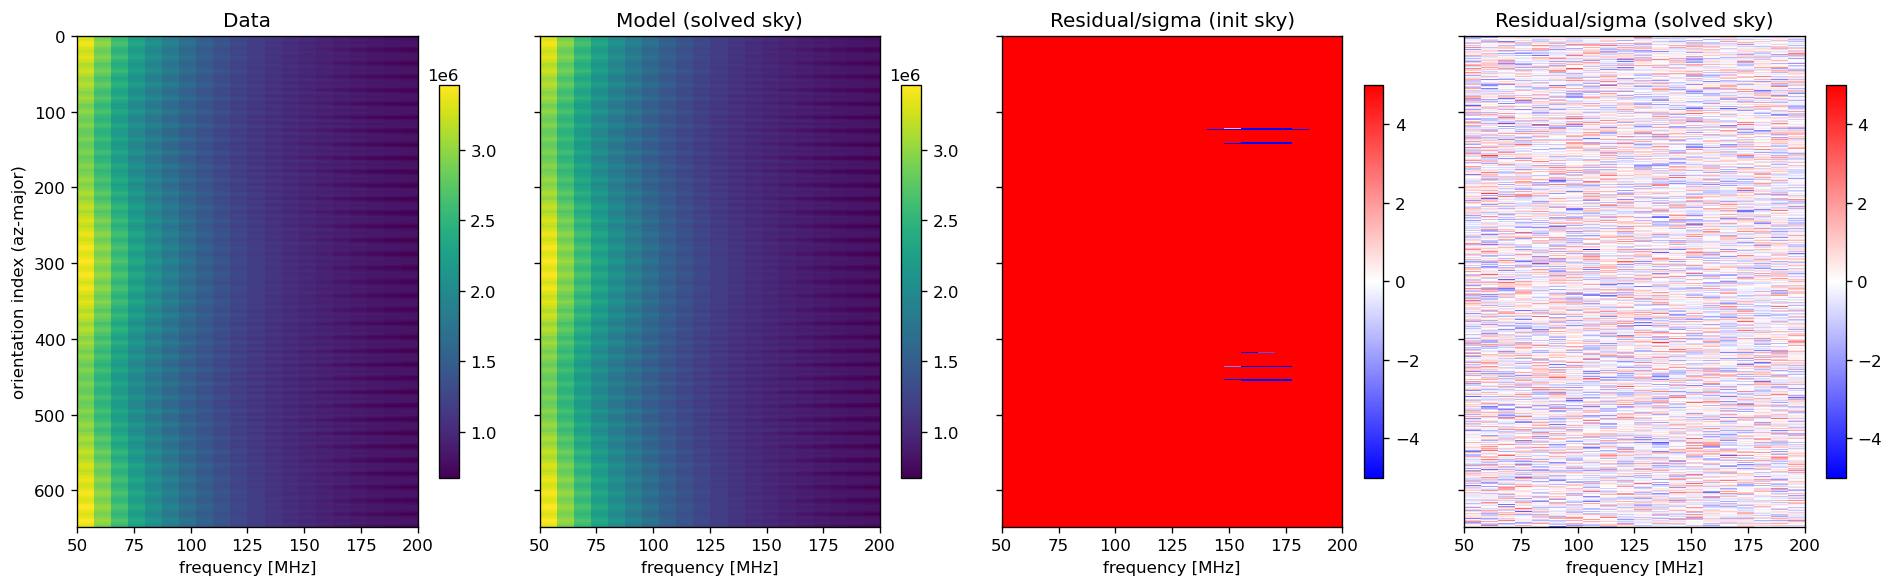

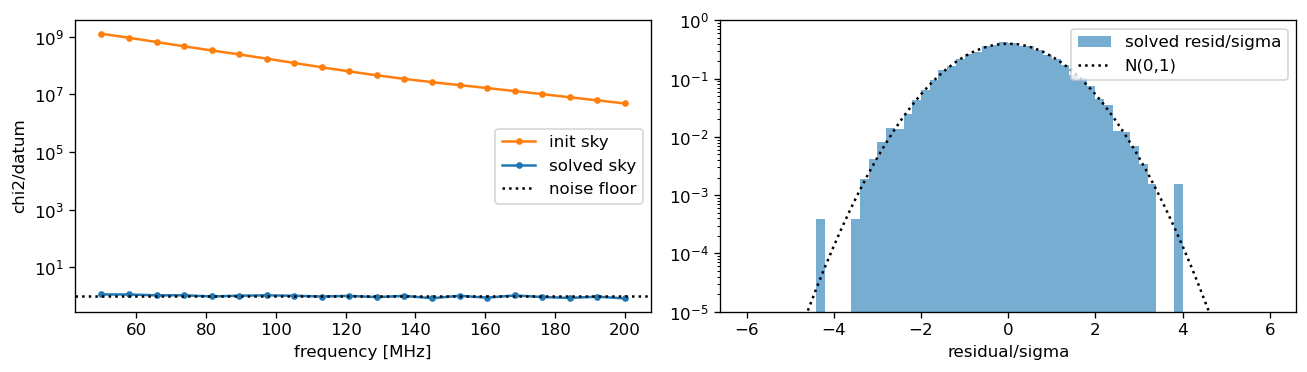

chi2/datum -- init 225472177.1   solved 1.007   (noise floor ~1)


In [12]:
# Data / model / residual diagnostics over the orientation scan.
model_init = np.asarray(
    fwd_fit.simulate(params_init["sky_coeffs"], params_init["beam_coeffs"], geom=geom_fit)
)[:, 0, :]
model_fit = np.asarray(
    fwd_fit.simulate(params_fit["sky_coeffs"], params_fit["beam_coeffs"], geom=geom_fit)
)[:, 0, :]
z_init = (data_obs - model_init) / SIGMA_K
z_fit = (data_obs - model_fit) / SIGMA_K

extent = [FREQS_MHZ[0], FREQS_MHZ[-1], data_obs.shape[0], 0]
zmax = max(5.0, np.percentile(np.abs(z_fit), 99))
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, img, ttl, kw in [
    (axes[0], data_obs, "Data", dict(cmap="viridis")),
    (axes[1], model_fit, "Model (solved sky)", dict(cmap="viridis")),
    (axes[2], z_init, "Residual/sigma (init sky)", dict(cmap="bwr", vmin=-zmax, vmax=zmax)),
    (axes[3], z_fit, "Residual/sigma (solved sky)", dict(cmap="bwr", vmin=-zmax, vmax=zmax)),
]:
    im = ax.imshow(img, aspect="auto", extent=extent, interpolation="nearest", **kw)
    ax.set_title(ttl)
    ax.set_xlabel("frequency [MHz]")
    plt.colorbar(im, ax=ax, shrink=0.8)
axes[0].set_ylabel("orientation index (az-major)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].semilogy(FREQS_MHZ, np.mean(z_init**2, axis=0), "C1.-", label="init sky")
ax[0].semilogy(FREQS_MHZ, np.mean(z_fit**2, axis=0), "C0.-", label="solved sky")
ax[0].axhline(1.0, color="k", ls=":", label="noise floor")
ax[0].set_xlabel("frequency [MHz]")
ax[0].set_ylabel("chi2/datum")
ax[0].legend()
edges = np.linspace(-6, 6, 61)
ax[1].hist(z_fit.ravel(), bins=edges, density=True, alpha=0.6, label="solved resid/sigma")
ax[1].plot(edges, np.exp(-edges**2 / 2) / np.sqrt(2 * np.pi), "k:", label="N(0,1)")
ax[1].set_xlabel("residual/sigma")
ax[1].set_yscale("log")
ax[1].set_ylim(1e-5, 1)
ax[1].legend()
plt.tight_layout()
plt.show()

print(f"chi2/datum -- init {np.mean(z_init**2):.1f}   solved {np.mean(z_fit**2):.3f}   (noise floor ~1)")

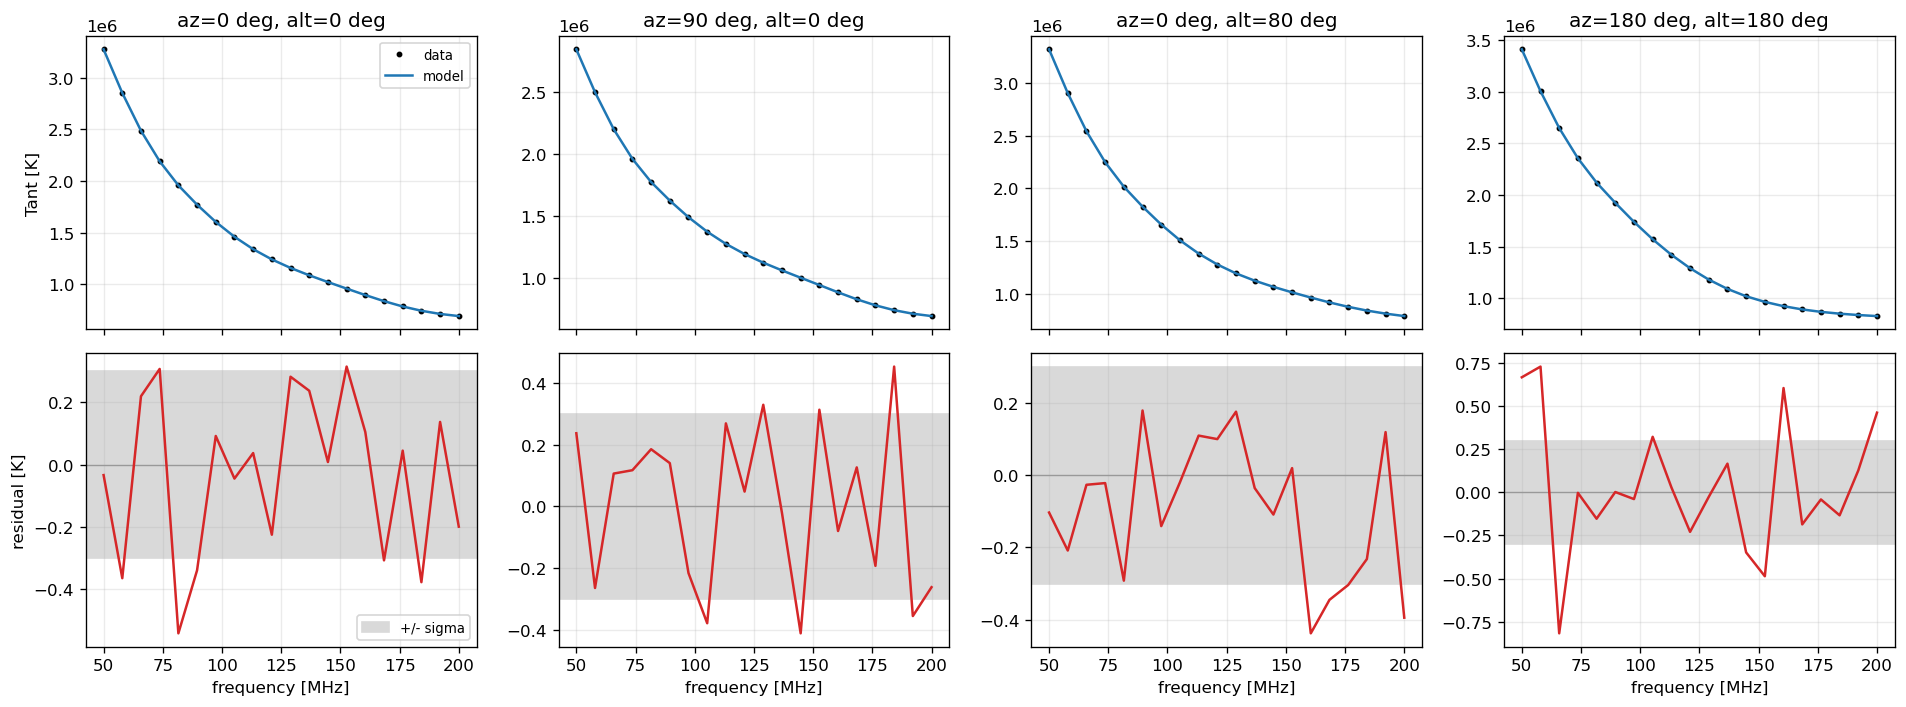

In [13]:
# Example spectra: data, fitted model, and residual for a few orientations.
spectra_orients = [(0, 0), (N_AZ // 4, 0), (0, N_ALT // 4), (N_AZ // 2, N_ALT // 2)]
fig, axes = plt.subplots(2, len(spectra_orients), figsize=(16, 6), sharex=True)
for j, (i_az, i_alt) in enumerate(spectra_orients):
    k = orientation_index(i_az, i_alt)
    axes[0, j].plot(FREQS_MHZ, data_obs[k], "k.", ms=5, label="data")
    axes[0, j].plot(FREQS_MHZ, model_fit[k], "C0-", lw=1.5, label="model")
    axes[0, j].set_title(f"az={az_deg[i_az]:.0f} deg, alt={alt_deg[i_alt]:.0f} deg")
    resid = data_obs[k] - model_fit[k]
    axes[1, j].axhspan(-SIGMA_K, SIGMA_K, color="0.85", label="+/- sigma")
    axes[1, j].axhline(0.0, color="0.6", lw=0.8)
    axes[1, j].plot(FREQS_MHZ, resid, "C3-")
    axes[1, j].set_xlabel("frequency [MHz]")
    for r in (0, 1):
        axes[r, j].grid(alpha=0.25)
axes[0, 0].set_ylabel("Tant [K]")
axes[0, 0].legend(fontsize=8)
axes[1, 0].set_ylabel("residual [K]")
axes[1, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Beam-Weighted, Terrain-Masked Sky And Recovered Map

The kernel the sky solver inverts is the BODY-frame beam sampled along each Galactic sky direction, gated by terrain visibility. For one orientation the panels below show terrain visibility, the beam on the sky, their product (the normalized integration weight), and the resulting weighted sky contribution — then the recovered visible sky and its error against truth. Only ever-visible pixels are constrained; blocked directions are left blank.

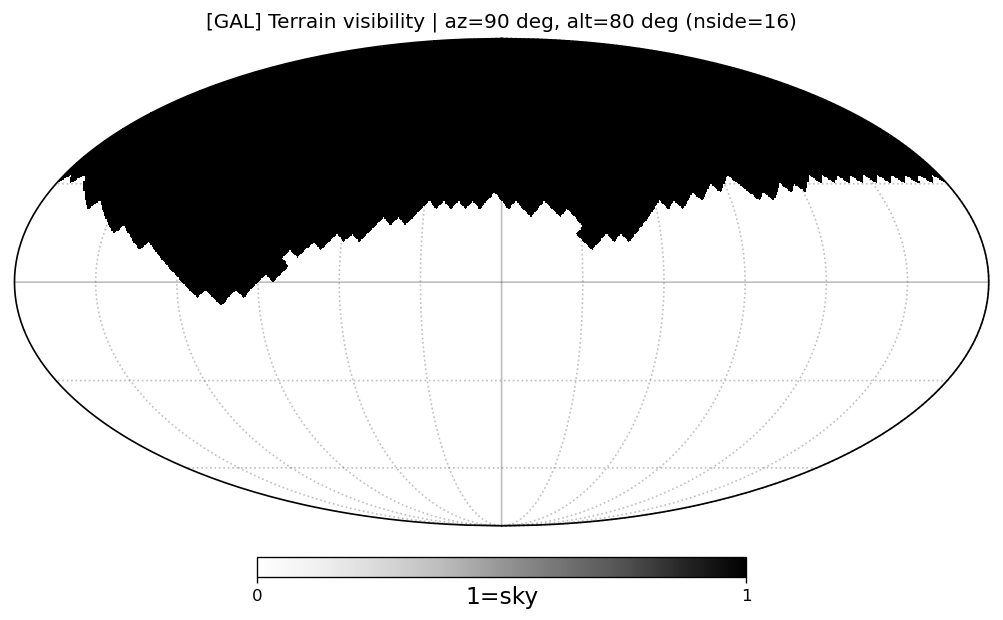

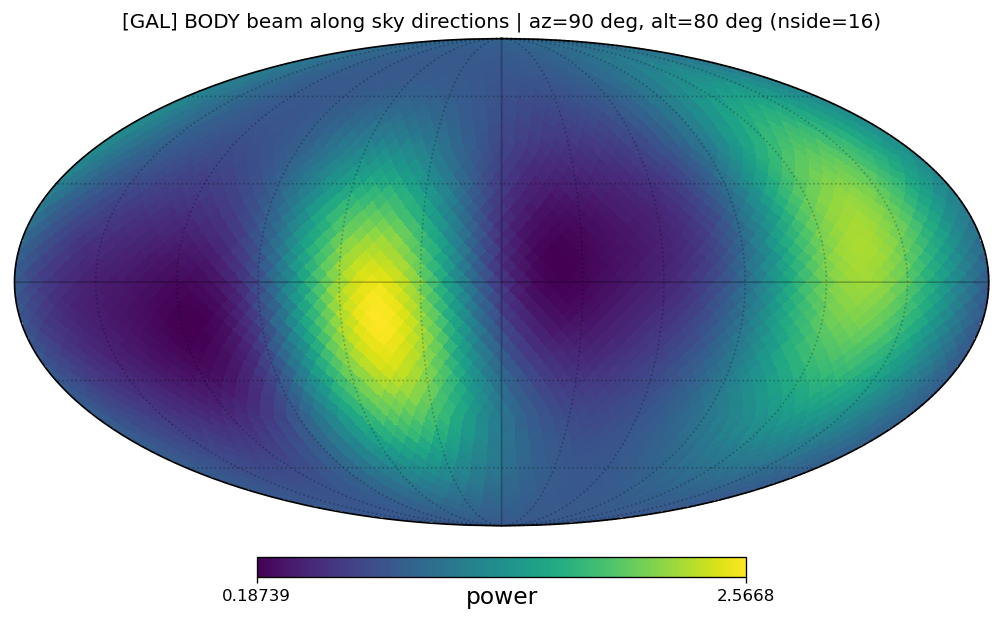

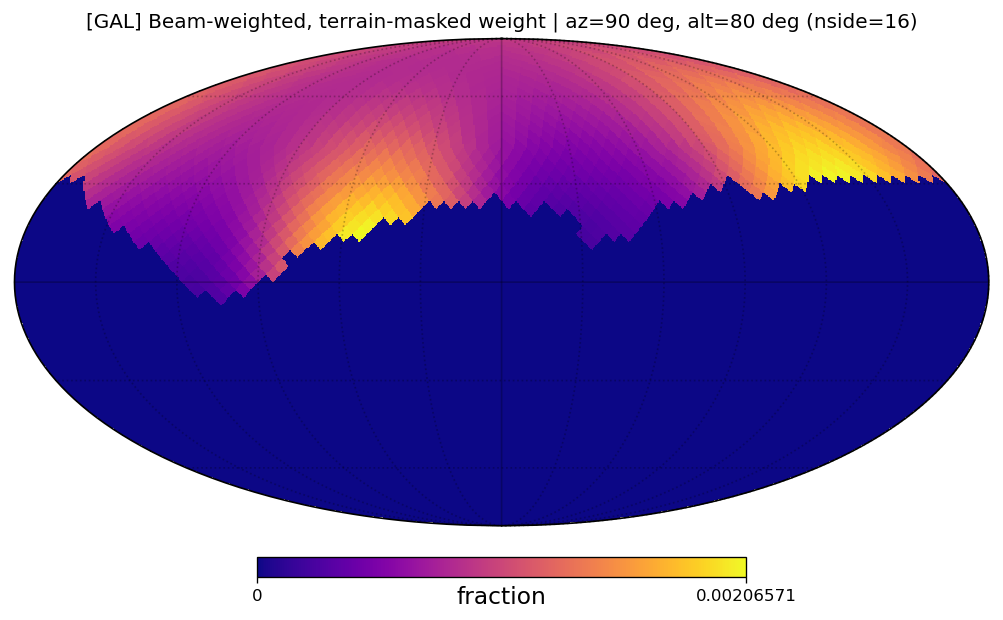

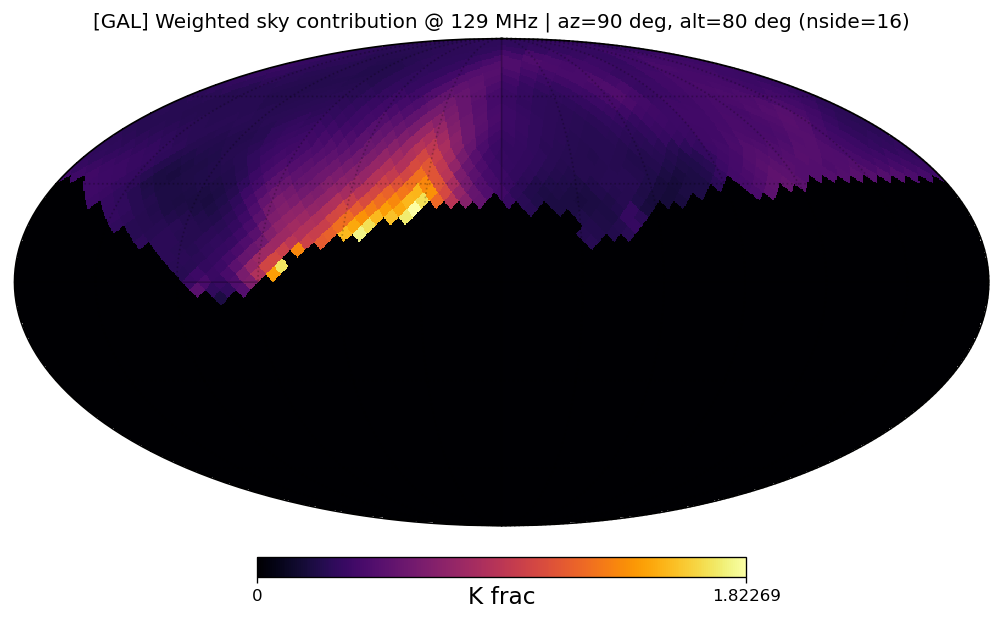

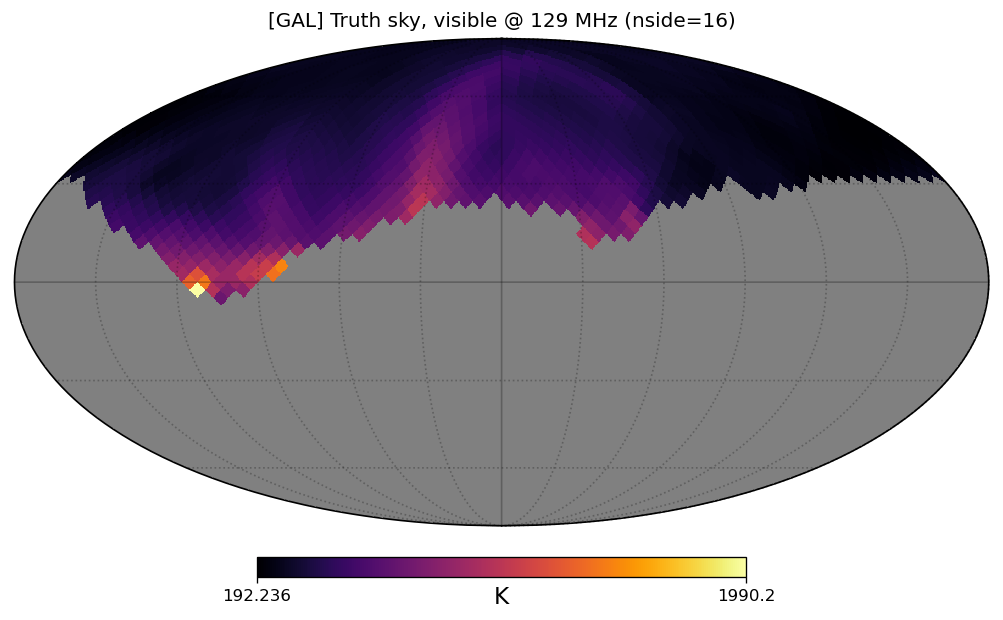

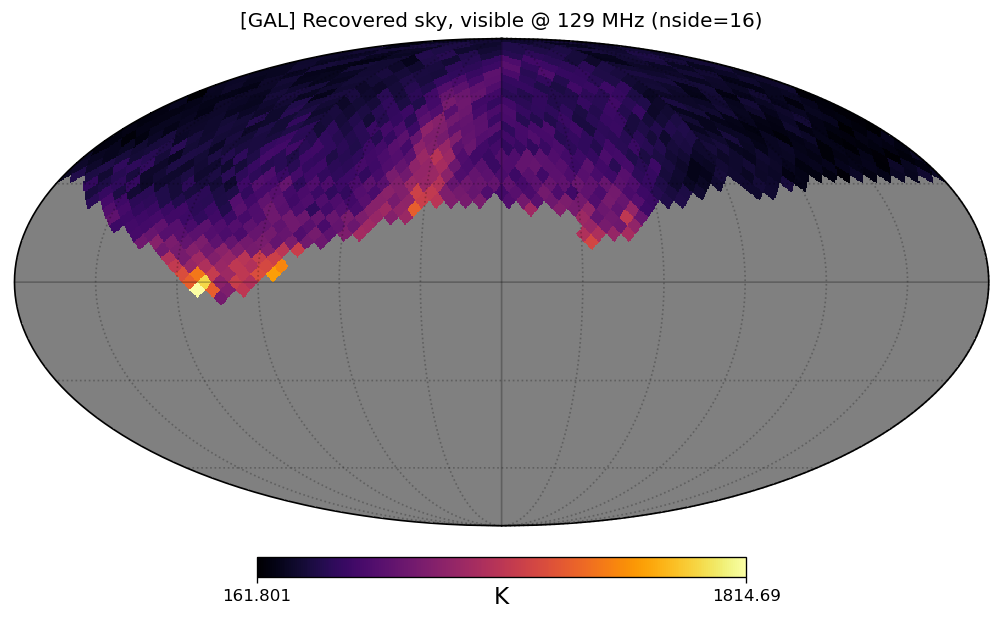

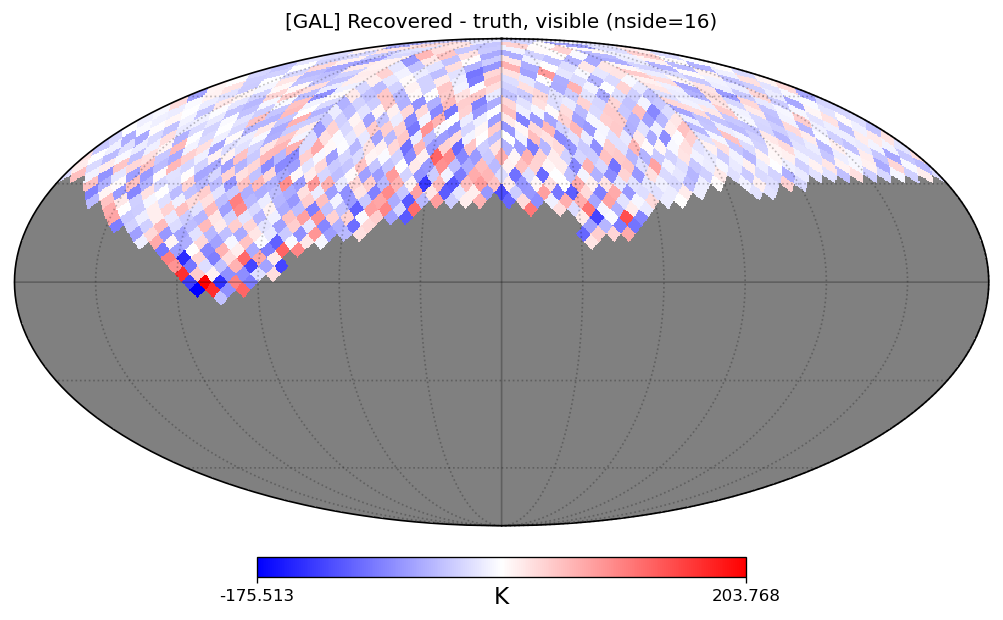

In [14]:
# Beam-weighted, terrain-masked sky for one representative orientation, and
# the recovered visible sky. The effective integration weight is the BODY
# beam sampled along each Galactic sky direction times the terrain
# visibility -- exactly the kernel the sky solver inverts.
crds_gal = hp_vectors(NSIDE_SKY)
crds_top = R_GAL2TOP @ crds_gal
i_az, i_alt = N_AZ // 4, N_ALT // 4
idx = orientation_index(i_az, i_alt)
title = f"az={az_deg[i_az]:.0f} deg, alt={alt_deg[i_alt]:.0f} deg"

crds_body = body_rots_scan[idx] @ crds_top
visible_gal = np.asarray(geom_full["terrain_masks_jax"])[idx]
beam_on_gal = nearest_beam_on_sky(beam_mid, beam.nside, crds_body)
eff_weight = normalize_weights(beam_on_gal * visible_gal)
weighted_sky = eff_weight * sky_maps[:, F_MID]

for m, t, cmap, unit in [
    (visible_gal, f"Terrain visibility | {title}", "Greys", "1=sky"),
    (beam_on_gal, f"BODY beam along sky directions | {title}", "viridis", "power"),
    (eff_weight, f"Beam-weighted, terrain-masked weight | {title}", "plasma", "fraction"),
    (weighted_sky, f"Weighted sky contribution @ {FREQS_MHZ[F_MID]:.0f} MHz | {title}", "inferno", "K frac"),
]:
    hp_moll(m, t, unit=unit, cmap=cmap, frame="GAL")
    plt.show()

# Recovered vs truth sky over the constrained (ever-visible) pixels.
vis = np.asarray(sky_mask)
CH = F_MID
truth_vis = np.where(vis, sky_maps[:, CH], np.nan)
fit_vis = np.where(vis, sky_fit_maps[:, CH], np.nan)
diff_vis = np.where(vis, sky_fit_maps[:, CH] - sky_maps[:, CH], np.nan)
hp_moll(truth_vis, f"Truth sky, visible @ {FREQS_MHZ[CH]:.0f} MHz", unit="K", cmap="inferno", frame="GAL")
plt.show()
hp_moll(fit_vis, f"Recovered sky, visible @ {FREQS_MHZ[CH]:.0f} MHz", unit="K", cmap="inferno", frame="GAL")
plt.show()
hp_moll(diff_vis, "Recovered - truth, visible", unit="K", cmap="bwr", frame="GAL")
plt.show()

## Notes For Follow-Up

Use this notebook when changing the forward model, terrain emission, beam rotations, or `sky_mask` logic. The most important sanity checks are: no implicit surface `z > 0` cut, terrain is the only Marjum blocker, full and reduced geometry agree, and the effective sky weights move smoothly with azimuth/altitude.

The recovery sections add an end-to-end check of the current fitter: a sky-only solve with the measured beam and terrain held fixed. The exact Cholesky sky solve (the core of `solver='fast-cg'`) should drive chi2/datum from a large initial value to ~1 in a single step, the solved residual waterfall should be white, and the recovered visible sky should track truth (residual error is set by sky coverage and the GSM mode count, not the optimizer). A joint sky+beam fit on the canyon needs a coarser beam parameterization — see `EIGSEP_Recovery_v001` for the `solver='fast-cg'` joint fit and its diagnostics.